In [37]:

import os
import json
import joblib
import optuna

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.kernel_ridge import KernelRidge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor

from scipy import stats
from scipy.stats import pearsonr

RANDOM_STATE = 42
OUTPUT_DIR = "./output_hybrid"
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.style.use("default")
sns.set_theme(style="whitegrid")


# 1. Data Loading

In [38]:
data = pd.read_csv(
    "calix_database_267.csv",
    sep=";",
    encoding="cp1251",
    decimal=","
)

print("Dataset shape:", data.shape)
data.head()


Dataset shape: (266, 27)


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
0,Group 1,1.log,5.0.4,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(C(C)(C)C)=CC(CC...,28-12-14-15,21-22-24-25,43-3-5-41,35-7-9-34,-0.995,1.327,...,2.59984,2.478,-2006.93685764,-139.177613,-6.029386,-0.616329,5.4131365906,-9.9169,-6.0708,3.846091
1,Group 1,2.log,5.0.4,OC1=C(CC2=C(C(CC3=C(O)C(CC4=CC(Br)=CC(CC1=C5)=...,32-5-3-34,22-21-19-18,15-14-12-25,28-9-7-29,0.383,-0.312,...,3.53626,10.409,-11671.36048181,-102.835983,-6.501089,-1.219379,5.2817871628,-10.8366,-7.3075,3.529071
2,Group 1,3.log,6.0.0,OC1=C(CC2=CC(C(C)(C)C)=CC3=C2O)C=C(C(C)(C)C)C=...,22-23-25-96,98-28-30-31,37-38-40-41,47-48-50-51,4.051,161.379,...,0.055869847,0.028,-4018.07954477,-278.371600,-5.983971,-0.646425,5.3376249556,-9.8131,-5.9846,3.828526
3,Group 1,4.log,5.0.4,OC1=C(SC2=C(C(SC3=C(O)C(SC4=CC(C(C)(C)C)=CC(SC...,25-24-22-21,15-14-12-28,34-9-7-35,41-5-3-43,-3.767,5.984,...,6.75529,8.595,-3441.79958704,-139.464044,-6.455184,-1.185991,5.2692699188,-9.8855,-7.0091,2.876384
4,Group 1,5.log,5.0.4,OC1=C(SC2=C(C(SC3=C(O)C(S4)=CC=C3)=CC=C2)O)C=C...,17-7-9-16,14-12-29-30,32-26-24-23,21-3-5-19,-7.619,7.266,...,5.05751,6.307,-2814.36372951,-88.794873,-6.770151,-1.287216,5.483015465799999,-10.1069,-7.2734,2.833483


In [39]:
print(data.dtypes)

Folder                    object
File                      object
Program Version           object
SMILES                    object
Atoms_1                   object
Atoms_2                   object
Atoms_3                   object
Atoms_4                   object
dihedral_1_orca          float64
dihedral_2_orca          float64
dihedral_3_orca          float64
dihedral_4_orca          float64
dihedral_1_xtb           float64
dihedral_2_xtb           float64
dihedral_3_xtb           float64
dihedral_4_xtb           float64
Number of Atoms            int64
Magnitude (Debye)         object
Dipole_xtb (Debye)       float64
Final Energy (Eh)         object
Total energy xtb (Eh)    float64
HOMO_orca (eV)           float64
LUMO_orca (eV)           float64
HOMO-LUMO Gap (eV)        object
HOMO_xtb (eV)            float64
LUMO_xtb (eV)            float64
HOMO-LUMO xtb (eV)       float64
dtype: object


## 1.1 Numeric conversion

In [40]:

numeric_cols = [
    "dihedral_1_orca",
    "dihedral_2_orca",
    "dihedral_3_orca",
    "dihedral_4_orca",
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
    "Number of Atoms",
    "Magnitude (Debye)",
    "Dipole_xtb (Debye)",
    "Final Energy (Eh)",
    "Total energy xtb (Eh)",
    "HOMO_orca (eV)",
    "LUMO_orca (eV)",
    "HOMO-LUMO Gap (eV)",
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors="coerce")

missing_summary = data[numeric_cols].isna().sum().sort_values(ascending=False)
print(missing_summary[missing_summary > 0])

data[data[numeric_cols].isna().any(axis=1)].head()


dihedral_1_orca      15
dihedral_2_orca      15
dihedral_3_orca      15
dihedral_4_orca      15
dihedral_1_xtb       15
dihedral_2_xtb       15
dihedral_3_xtb       15
dihedral_4_xtb       15
Magnitude (Debye)     1
dtype: int64


,Folder,File,Program Version,SMILES,Atoms_1,Atoms_2,Atoms_3,Atoms_4,dihedral_1_orca,dihedral_2_orca,...,Magnitude (Debye),Dipole_xtb (Debye),Final Energy (Eh),Total energy xtb (Eh),HOMO_orca (eV),LUMO_orca (eV),HOMO-LUMO Gap (eV),HOMO_xtb (eV),LUMO_xtb (eV),HOMO-LUMO xtb (eV)
75,Group 7,72.log,5.0.4,OC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.201630,11.289,-850.787026,-51.096075,-6.698532,-2.911495,3.787092,-9.8632,-9.0211,0.842072
76,Group 7,73.log,5.0.4,OCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O)C=C2,NaN,NaN,NaN,NaN,NaN,NaN,...,7.158290,11.346,-1043.492294,-64.642234,-6.632328,-2.888829,3.743554,-9.8054,-8.9571,0.848376
77,Group 7,74.log,5.0.4,CCCCCCCCOC(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=...,NaN,NaN,NaN,NaN,NaN,NaN,...,8.166360,12.713,-1164.483810,-76.409827,-6.579919,-2.857427,3.722547,-9.7315,-8.9131,0.818400
78,Group 7,75.log,5.0.4,OCCN(CC)C(C=C1)=CC=C1/N=N/C2=CC=C([N+]([O-])=O...,NaN,NaN,NaN,NaN,NaN,NaN,...,9.153920,14.413,-1062.864677,-67.186200,-5.984678,-2.711848,3.272878,-9.4801,-8.6633,0.816793
112,Group 9,109.log,6.0.0,CC(C)(C)C(C=C1)=CC=C1OCC2=N3N([H][N]4C(COC5=CC...,NaN,NaN,NaN,NaN,NaN,NaN,...,2.149567,2.000,-3832.915063,-255.867584,-5.876433,-0.957637,4.918869,-9.9602,-6.9416,3.018645


## 1.2 Feature engineering

In [41]:

dihedral_cols = [
    "dihedral_1_xtb",
    "dihedral_2_xtb",
    "dihedral_3_xtb",
    "dihedral_4_xtb",
]

for col in dihedral_cols:
    data[col + "_exists"] = data[col].notna().astype(int)
    angle_rad = np.deg2rad(data[col].fillna(0.0))
    data[col + "_sin"] = np.sin(angle_rad)
    data[col + "_cos"] = np.cos(angle_rad)

data["delta_homo"] = data["HOMO_orca (eV)"] - data["HOMO_xtb (eV)"]
data["delta_lumo"] = data["LUMO_orca (eV)"] - data["LUMO_xtb (eV)"]

# Energy target is normalized by molecule size
data["delta_energy_per_atom"] = (data["Final Energy (Eh)"] - data["Total energy xtb (Eh)"]) / data["Number of Atoms"]

# Additional informative descriptors derived from xTB outputs
data["energy_xtb_per_atom"] = data["Total energy xtb (Eh)"] / data["Number of Atoms"]
data["dipole_xtb_per_atom"] = data["Dipole_xtb (Debye)"] / data["Number of Atoms"]
data["abs_homo_xtb"] = data["HOMO_xtb (eV)"].abs()
data["abs_lumo_xtb"] = data["LUMO_xtb (eV)"].abs()

data[[
    "delta_homo",
    "delta_lumo",
    "delta_energy_per_atom",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom"
]].describe()


,delta_homo,delta_lumo,delta_energy_per_atom,energy_xtb_per_atom,dipole_xtb_per_atom
count,266.000000,266.000000,266.000000,266.000000,266.000000
mean,3.746284,5.899618,-39.001187,-1.492937,0.041591
std,0.234316,0.327861,32.820073,0.184029,0.052638
min,2.818577,2.832077,-270.898106,-2.437544,0.000000
25%,3.659556,5.802279,-33.901479,-1.504880,0.011109
50%,3.763504,5.911097,-31.112182,-1.452315,0.026224
75%,3.865637,5.996225,-24.722584,-1.414164,0.052722
max,5.428766,6.929053,-17.100044,-1.267910,0.418111


# 2. Exploratory Data Analysis (EDA)

## 2.1 95% confidence intervals for targets

In [42]:

target_cols = ["delta_homo", "delta_lumo", "delta_energy_per_atom"]

metrics = {}

for feature in target_cols:
    mean = data[feature].mean()
    std_dev = data[feature].std()
    n = len(data)
    std_error = std_dev / np.sqrt(n)
    z_score = stats.norm.ppf(0.975)
    margin_of_error = z_score * std_error

    metrics[feature] = {
        "mean": mean,
        "std": std_dev,
        "95% CI Lower": mean - margin_of_error,
        "95% CI Upper": mean + margin_of_error,
        "95% CI Width": 2 * margin_of_error
    }

ci_df = pd.DataFrame(metrics).T
ci_df


,mean,std,95% CI Lower,95% CI Upper,95% CI Width
delta_homo,3.746284,0.234316,3.718125,3.774442,0.056317
delta_lumo,5.899618,0.327861,5.860218,5.939018,0.078800
delta_energy_per_atom,-39.001187,32.820073,-42.945277,-35.057097,7.888180


## 2.2 Baseline xTB vs ORCA correlations

In [43]:

print("HOMO baseline correlation")
print(data[["HOMO_xtb (eV)", "HOMO_orca (eV)"]].corr())
print()
print("LUMO baseline correlation")
print(data[["LUMO_xtb (eV)", "LUMO_orca (eV)"]].corr())
print()
print("Final energy baseline correlation")
print(data[["Total energy xtb (Eh)", "Final Energy (Eh)"]].corr())


HOMO baseline correlation
                HOMO_xtb (eV)  HOMO_orca (eV)
HOMO_xtb (eV)        1.000000        0.838009
HOMO_orca (eV)       0.838009        1.000000

LUMO baseline correlation
                LUMO_xtb (eV)  LUMO_orca (eV)
LUMO_xtb (eV)        1.000000        0.906562
LUMO_orca (eV)       0.906562        1.000000

Final energy baseline correlation
                       Total energy xtb (Eh)  Final Energy (Eh)
Total energy xtb (Eh)               1.000000           0.819912
Final Energy (Eh)                   0.819912           1.000000


## 2.3 Scatter plots of xTB features vs target deltas

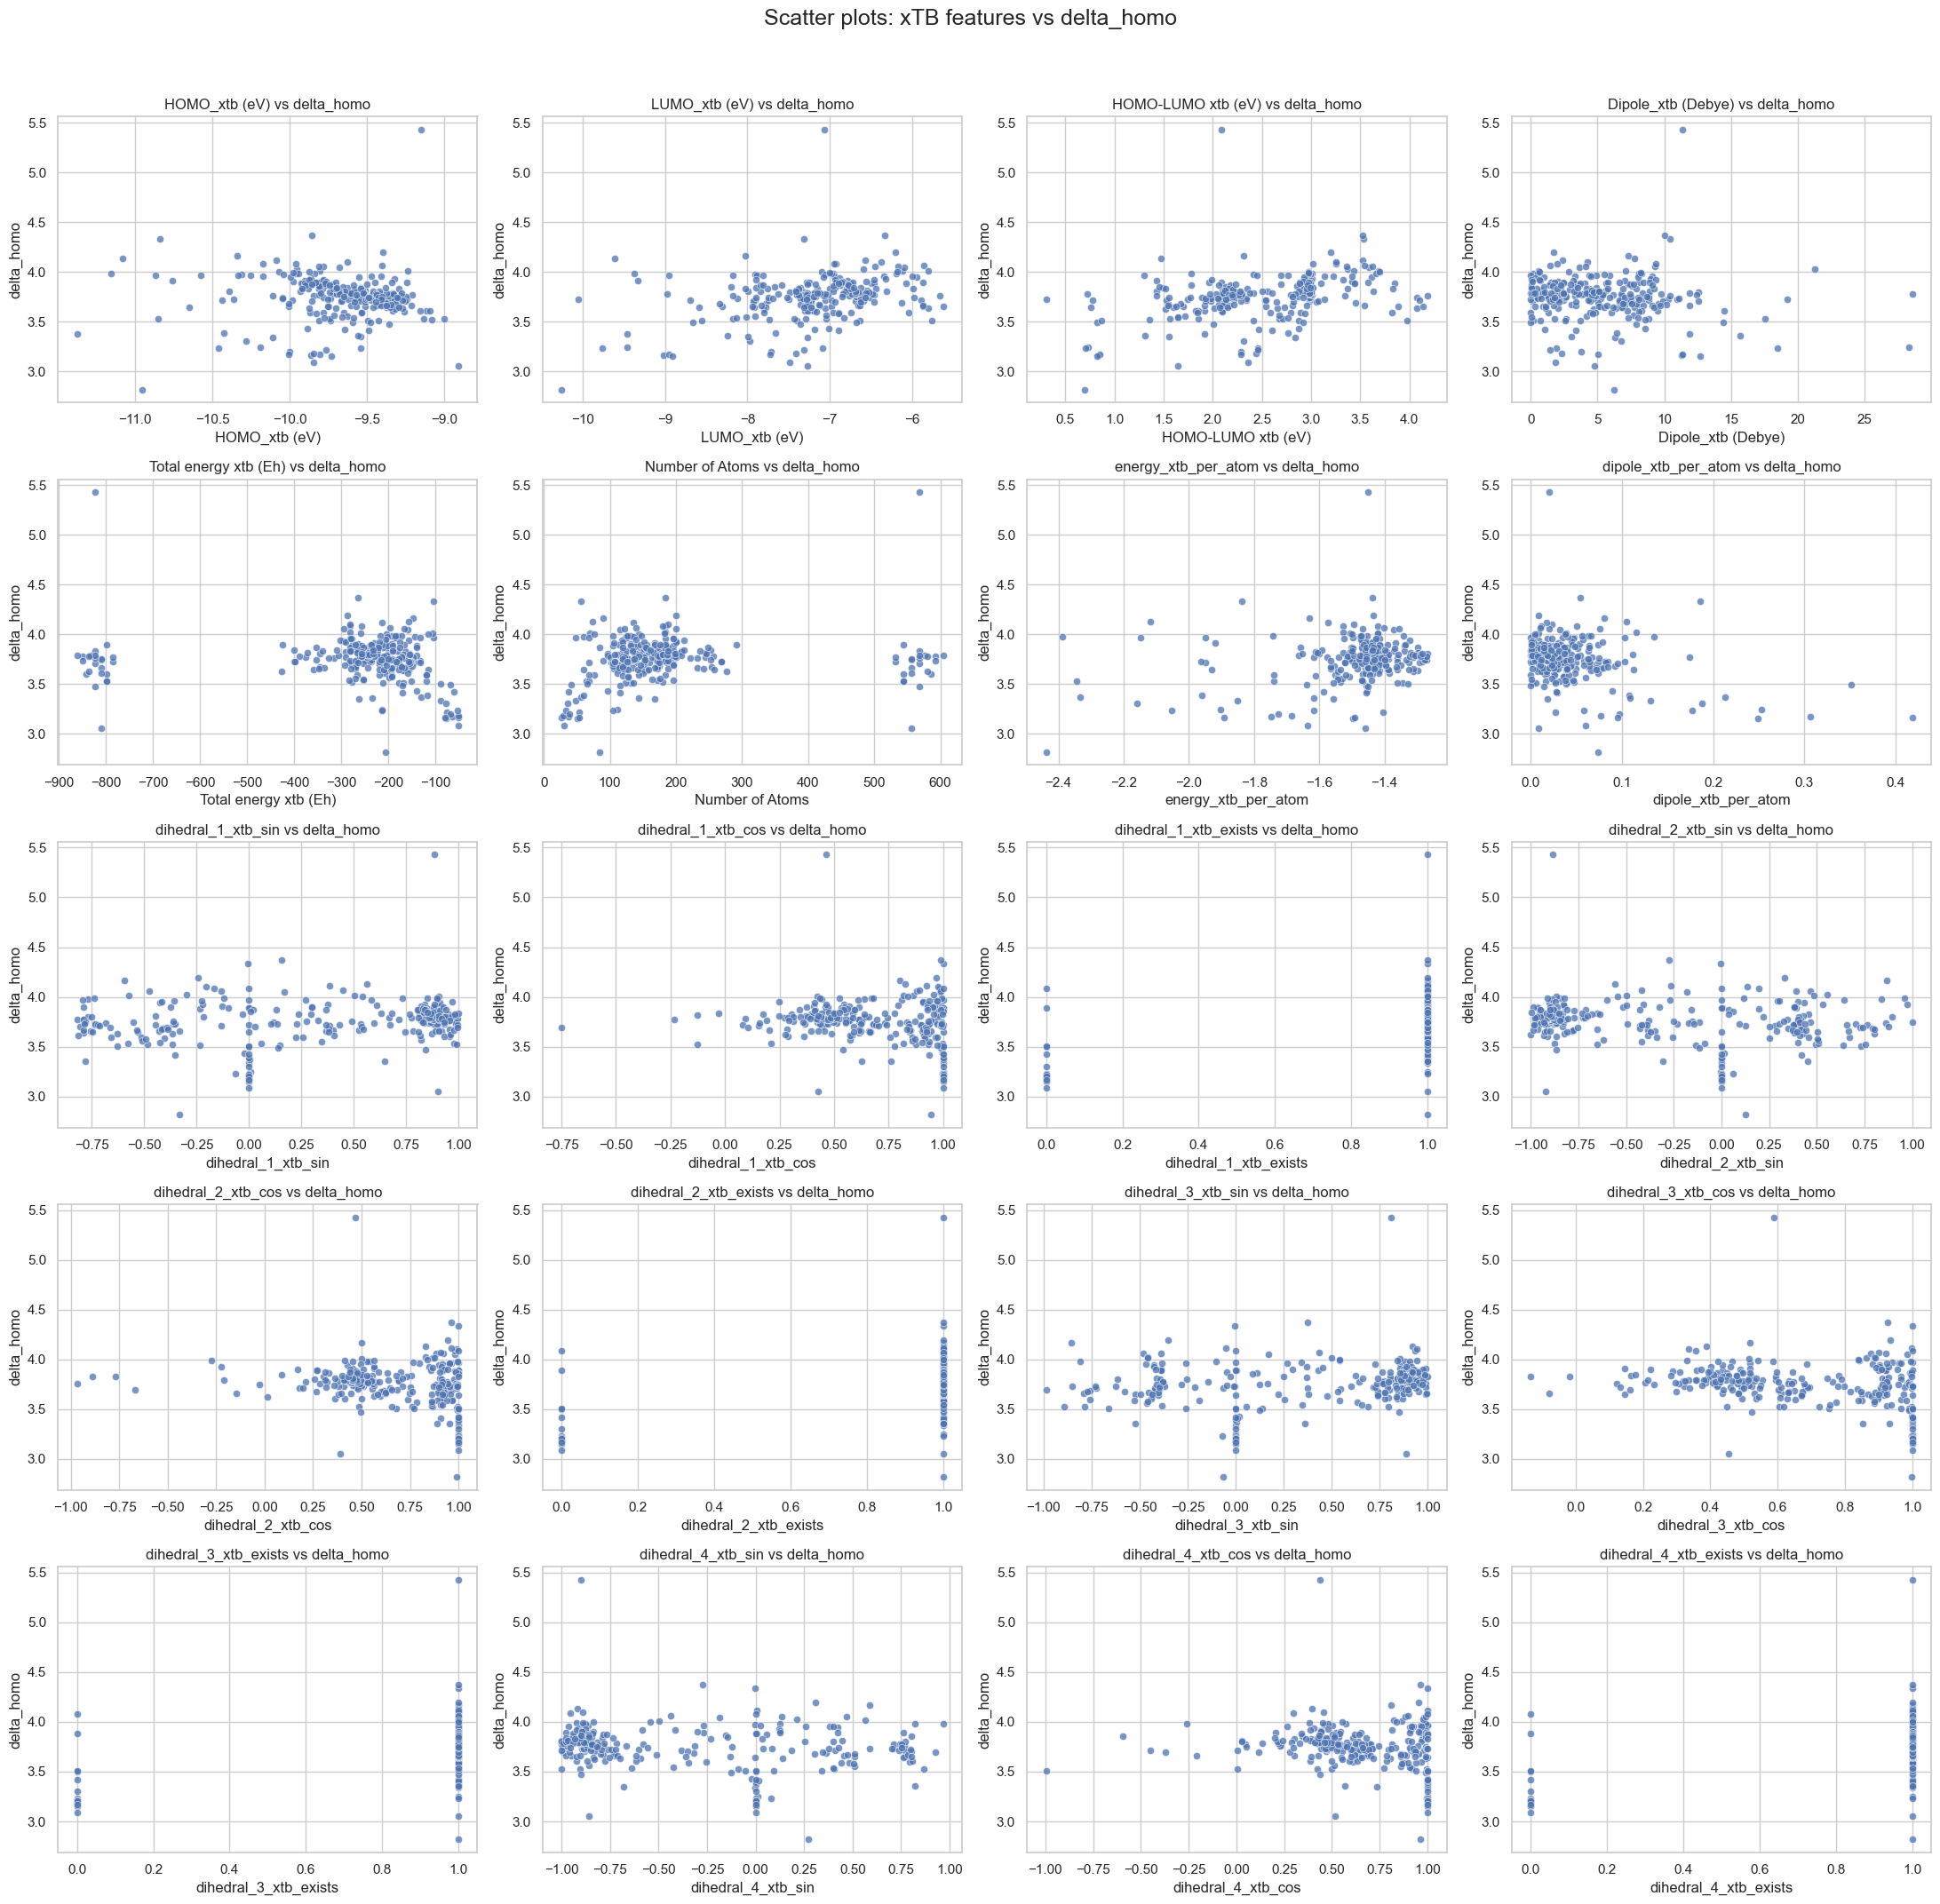

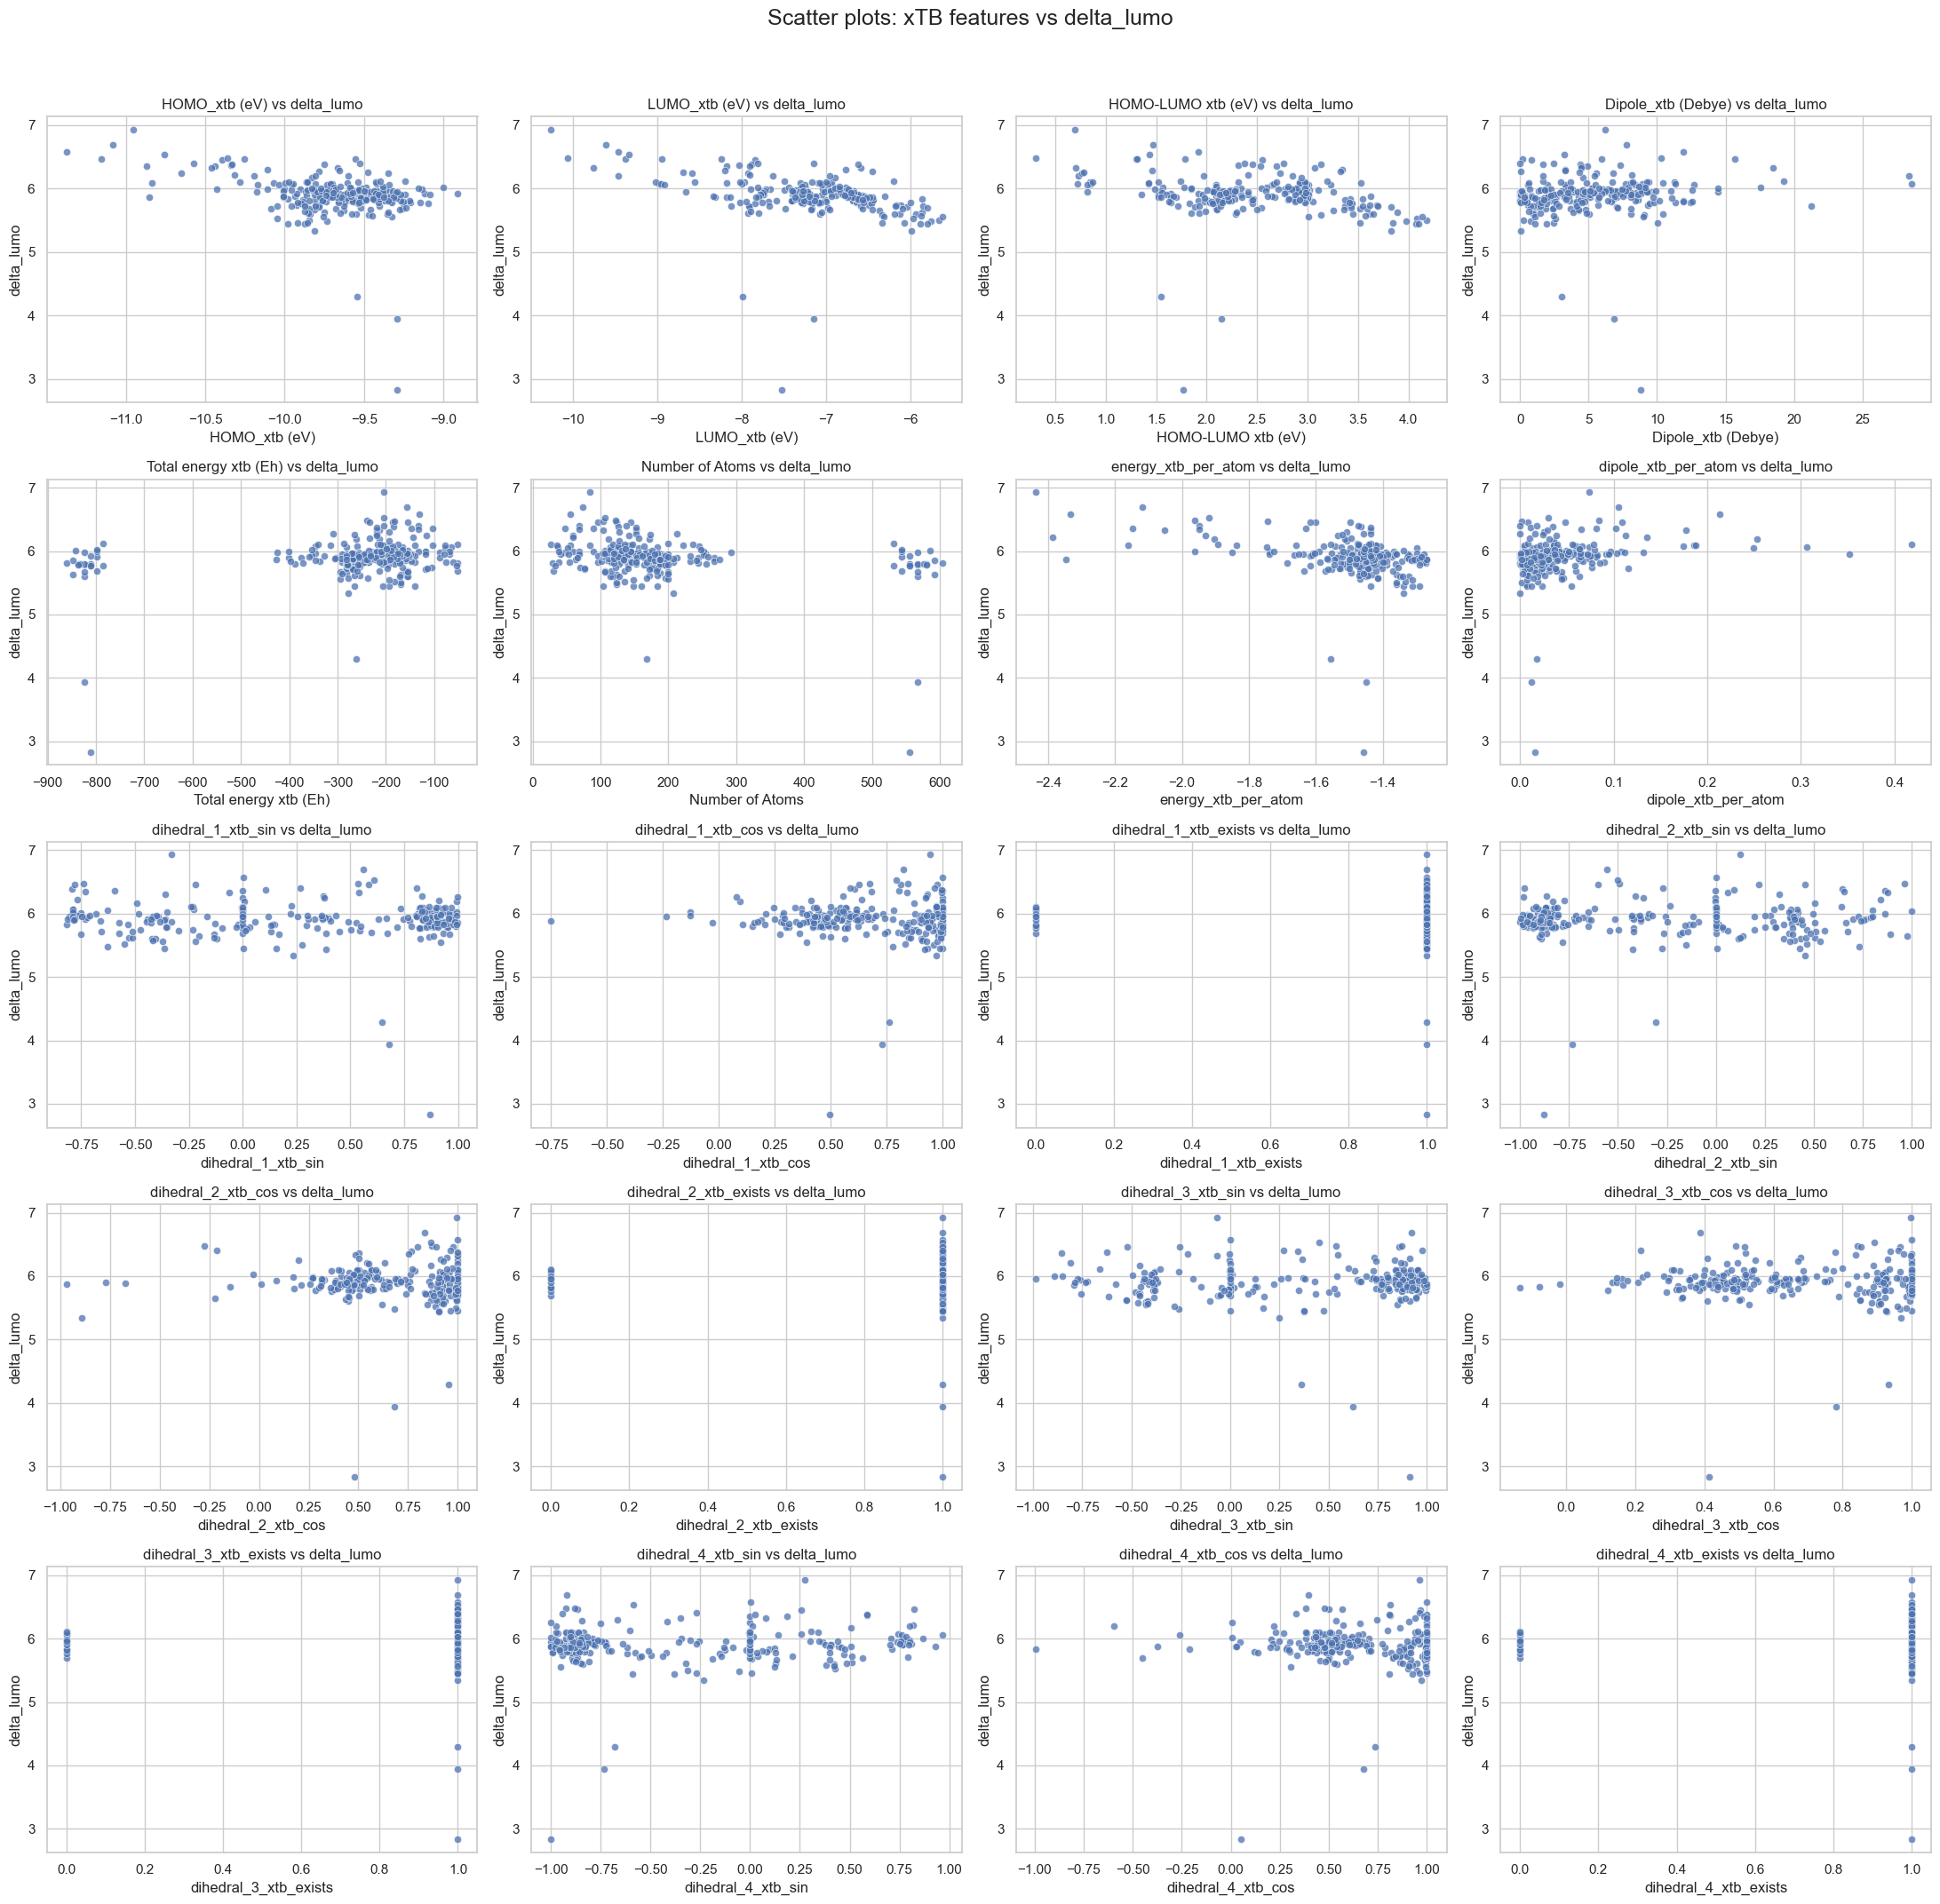

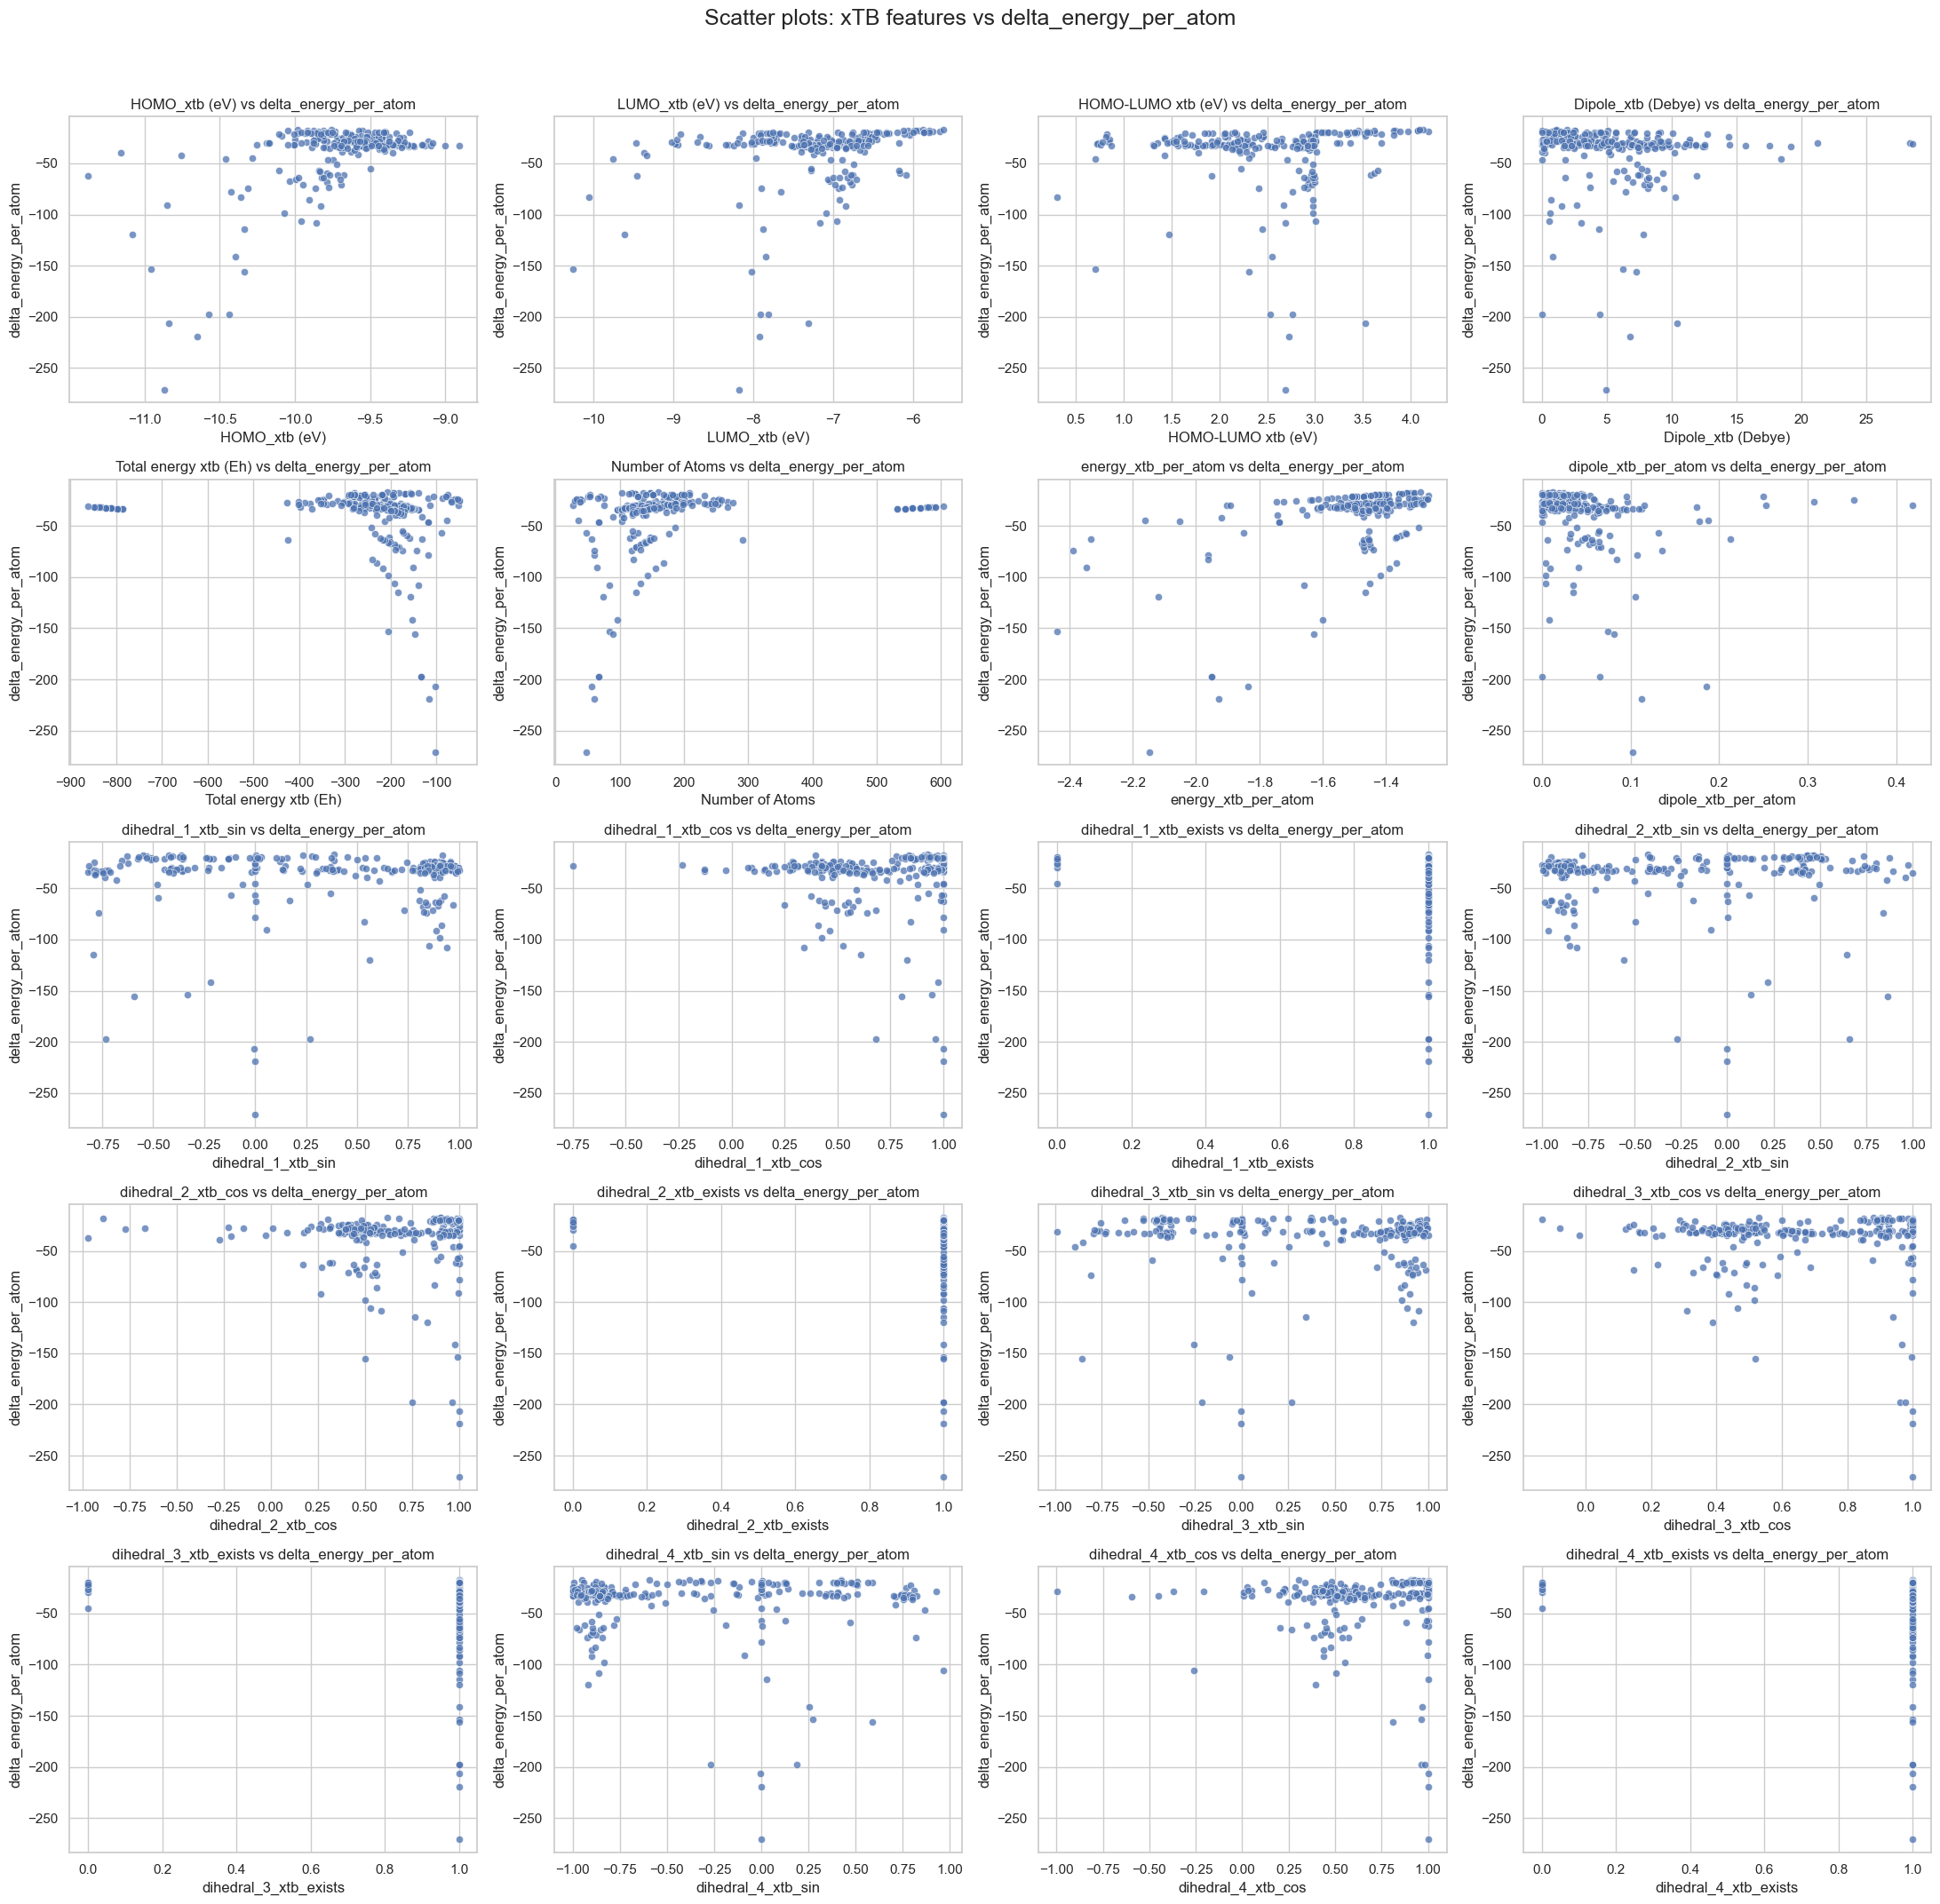

In [44]:

xtb_features_eda = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

targets_eda = ["delta_homo", "delta_lumo", "delta_energy_per_atom"]

for target in targets_eda:
    n_cols = 4
    n_rows = int(np.ceil(len(xtb_features_eda) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4.2 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(xtb_features_eda):
        sns.scatterplot(data=data, x=feature, y=target, ax=axes[i], s=35, alpha=0.75)
        axes[i].set_title(f"{feature} vs {target}")

    for j in range(len(xtb_features_eda), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Scatter plots: xTB features vs {target}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()


## 2.4 Correlation matrix between xTB features and target deltas

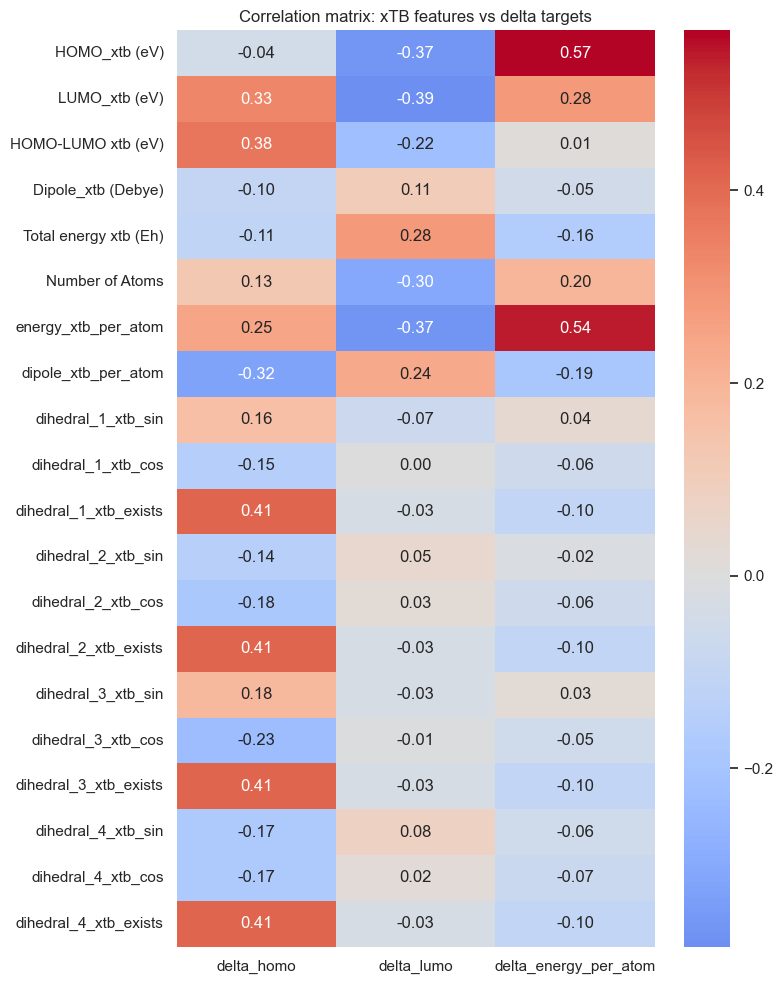

,delta_homo,delta_lumo,delta_energy_per_atom
HOMO_xtb (eV),-0.044066,-0.365694,0.566142
LUMO_xtb (eV),0.333987,-0.385234,0.279041
HOMO-LUMO xtb (eV),0.375443,-0.223144,0.009818
Dipole_xtb (Debye),-0.098313,0.106998,-0.048355
Total energy xtb (Eh),-0.111170,0.277068,-0.160143
Number of Atoms,0.127586,-0.304288,0.196525
energy_xtb_per_atom,0.250236,-0.367237,0.539047
dipole_xtb_per_atom,-0.323767,0.237923,-0.190697
dihedral_1_xtb_sin,0.159231,-0.071440,0.036416
dihedral_1_xtb_cos,-0.146826,0.001893,-0.058892


In [45]:

correlation_matrix = data[xtb_features_eda + targets_eda].corr().loc[xtb_features_eda, targets_eda]
plt.figure(figsize=(8, 10))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation matrix: xTB features vs delta targets")
plt.tight_layout()
plt.show()

correlation_matrix


## 2.5 Ranked correlations

In [46]:

average_correlations = correlation_matrix.abs().mean(axis=1).sort_values(ascending=False)
max_correlations = correlation_matrix.abs().max(axis=1).sort_values(ascending=False)

print("Average absolute correlation")
display(average_correlations.to_frame("avg_abs_corr"))

print("Maximum absolute correlation")
display(max_correlations.to_frame("max_abs_corr"))


Average absolute correlation


,avg_abs_corr
energy_xtb_per_atom,0.385507
LUMO_xtb (eV),0.332754
HOMO_xtb (eV),0.325301
dipole_xtb_per_atom,0.250796
Number of Atoms,0.209466
HOMO-LUMO xtb (eV),0.202802
Total energy xtb (Eh),0.182794
dihedral_3_xtb_exists,0.180907
dihedral_2_xtb_exists,0.180907
dihedral_1_xtb_exists,0.180907


Maximum absolute correlation


,max_abs_corr
HOMO_xtb (eV),0.566142
energy_xtb_per_atom,0.539047
dihedral_3_xtb_exists,0.412430
dihedral_2_xtb_exists,0.412430
dihedral_1_xtb_exists,0.412430
dihedral_4_xtb_exists,0.412430
LUMO_xtb (eV),0.385234
HOMO-LUMO xtb (eV),0.375443
dipole_xtb_per_atom,0.323767
Number of Atoms,0.304288


## 2.6 Distributions

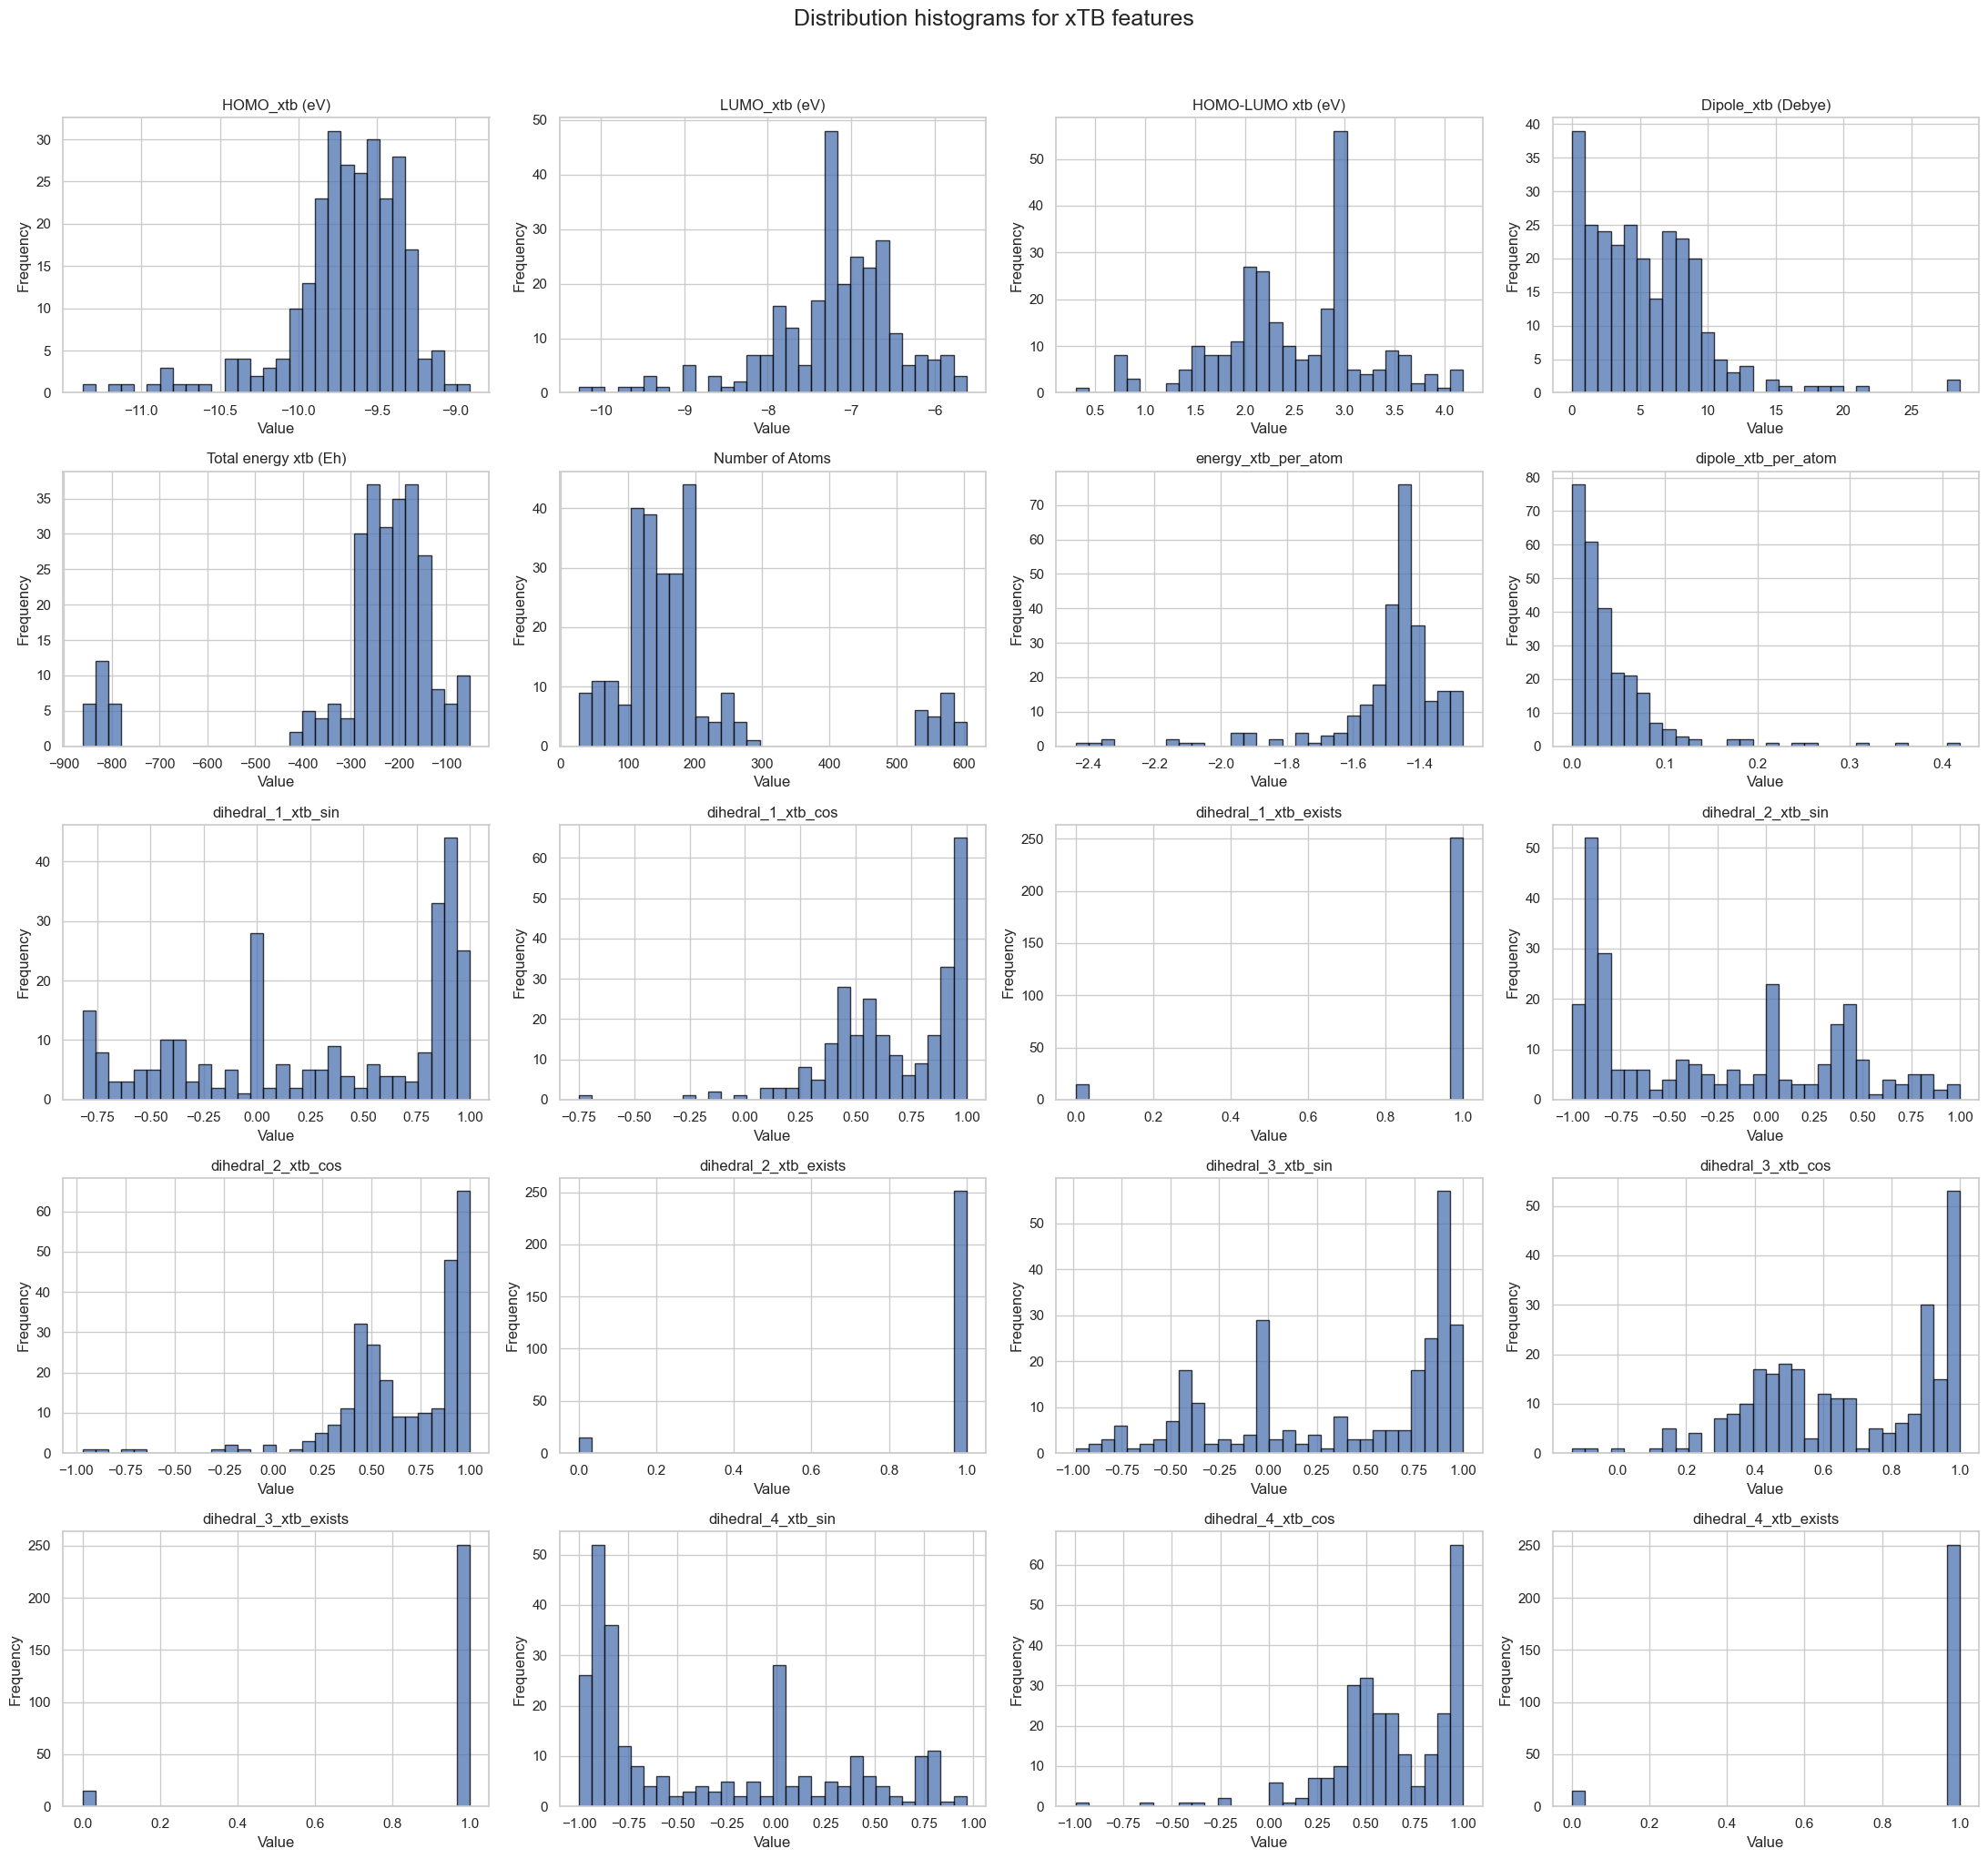

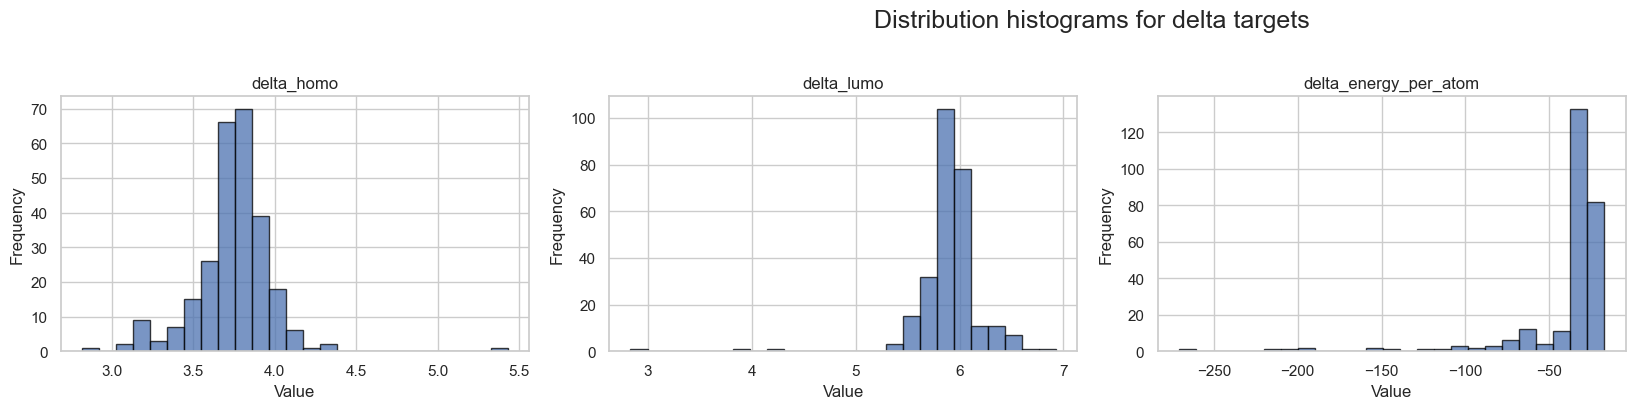

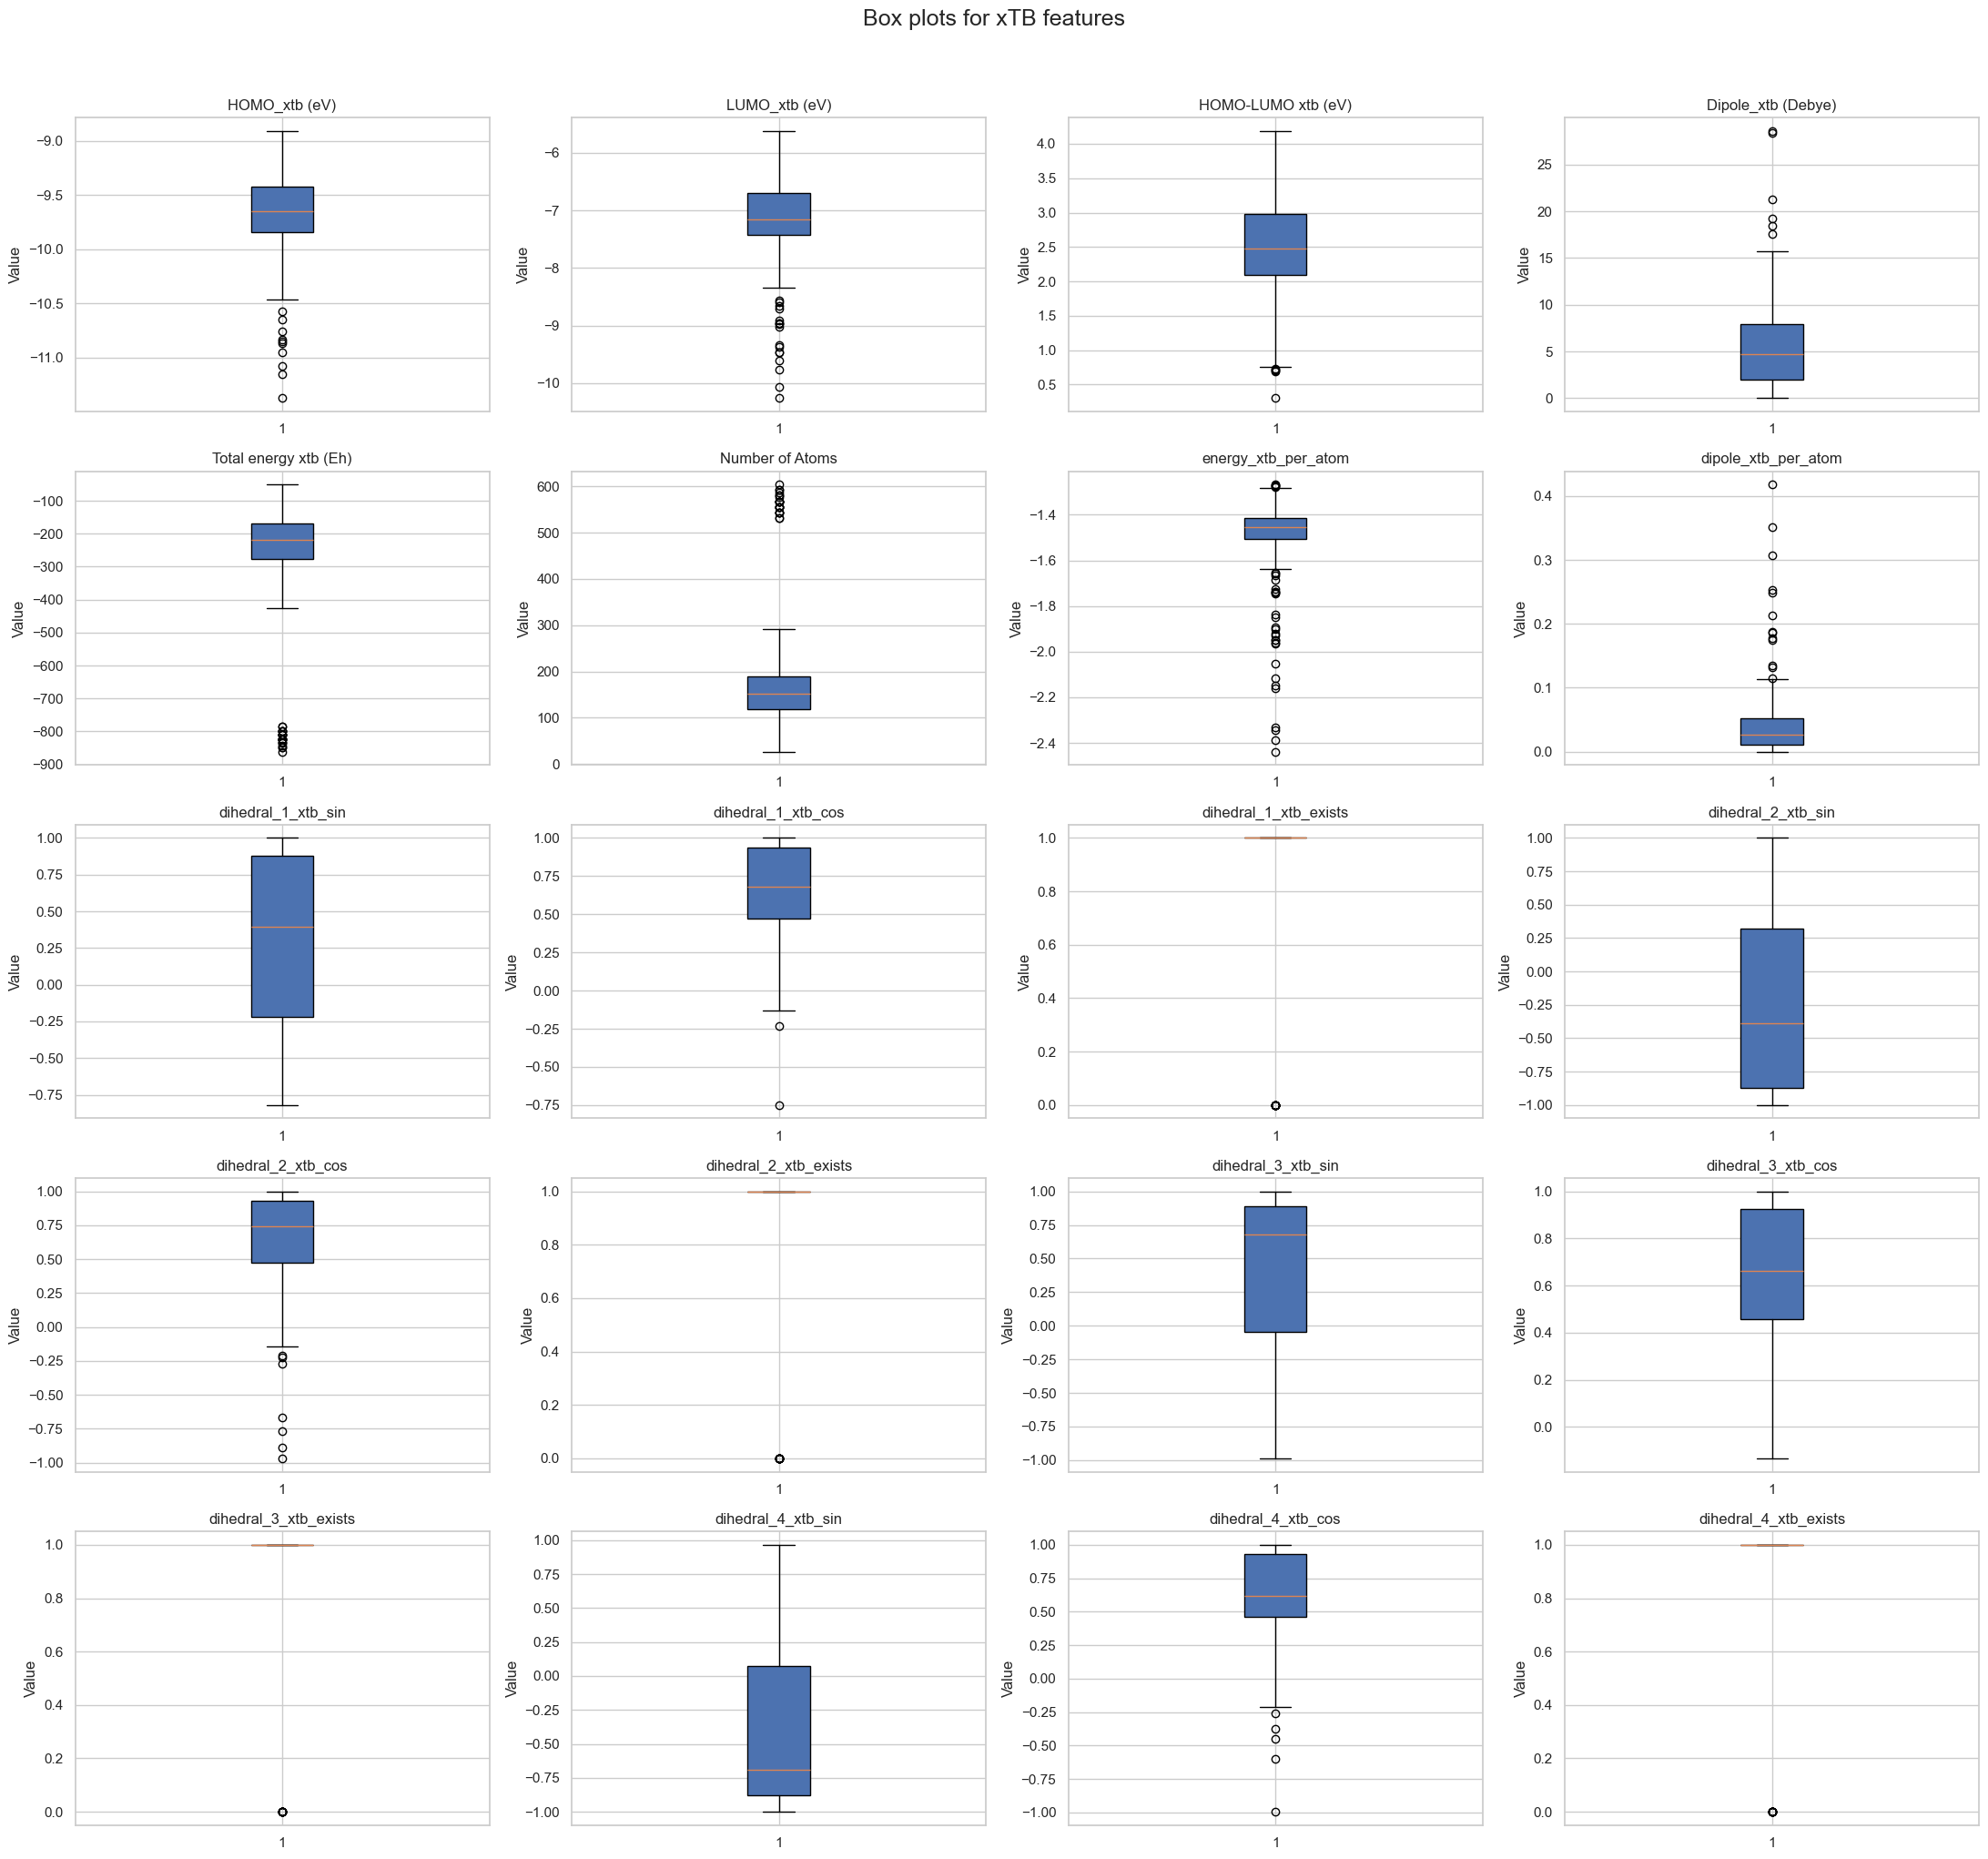

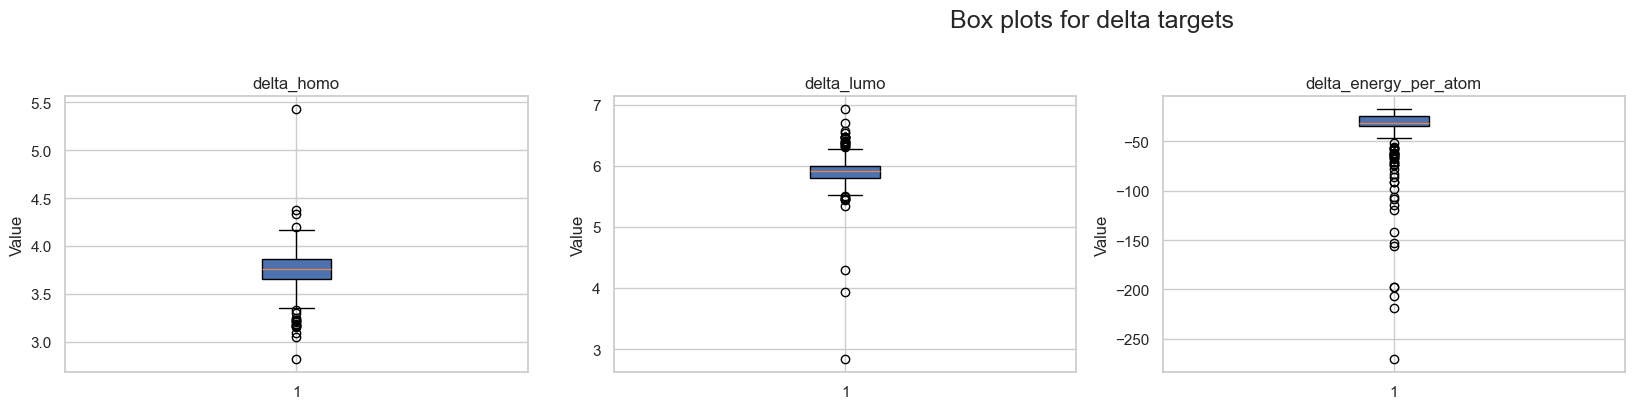

In [47]:

def plot_histograms(features, title, bins=30):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].hist(data[feature].dropna(), bins=bins, edgecolor="black", alpha=0.75)
        axes[i].set_title(feature)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_boxplots(features, title):
    n_cols = 4
    n_rows = int(np.ceil(len(features) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, feature in enumerate(features):
        axes[i].boxplot(data[feature].dropna(), vert=True, patch_artist=True)
        axes[i].set_title(feature)
        axes[i].set_ylabel("Value")

    for j in range(len(features), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(title, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

plot_histograms(xtb_features_eda, "Distribution histograms for xTB features")
plot_histograms(targets_eda, "Distribution histograms for delta targets", bins=25)

plot_boxplots(xtb_features_eda, "Box plots for xTB features")
plot_boxplots(targets_eda, "Box plots for delta targets")


## 2.7 P-values for Pearson correlations

In [48]:

p_values = pd.DataFrame(index=xtb_features_eda, columns=targets_eda)

for xtb in xtb_features_eda:
    for target in targets_eda:
        _, p_value = pearsonr(data[xtb], data[target])
        p_values.loc[xtb, target] = p_value

p_values


,delta_homo,delta_lumo,delta_energy_per_atom
HOMO_xtb (eV),0.474201,0.0,0.0
LUMO_xtb (eV),0.0,0.0,0.000004
HOMO-LUMO xtb (eV),0.0,0.000244,0.873372
Dipole_xtb (Debye),0.10965,0.081531,0.432226
Total energy xtb (Eh),0.070264,0.000004,0.008885
Number of Atoms,0.037566,0.0,0.001275
energy_xtb_per_atom,0.000037,0.0,0.0
dipole_xtb_per_atom,0.0,0.000089,0.001783
dihedral_1_xtb_sin,0.009285,0.245583,0.5543
dihedral_1_xtb_cos,0.016558,0.975486,0.338667


# 3. Hybrid Modeling: Ridge for HOMO/LUMO, XGBoost for Final Energy

## 3.1 Define feature and target sets

In [49]:

features_common = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Dipole_xtb (Debye)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "energy_xtb_per_atom",
    "dipole_xtb_per_atom",
    "abs_homo_xtb",
    "abs_lumo_xtb",
    "dihedral_1_xtb_sin",
    "dihedral_1_xtb_cos",
    "dihedral_1_xtb_exists",
    "dihedral_2_xtb_sin",
    "dihedral_2_xtb_cos",
    "dihedral_2_xtb_exists",
    "dihedral_3_xtb_sin",
    "dihedral_3_xtb_cos",
    "dihedral_3_xtb_exists",
    "dihedral_4_xtb_sin",
    "dihedral_4_xtb_cos",
    "dihedral_4_xtb_exists",
]

target_homo = "delta_homo"
target_lumo = "delta_lumo"
target_energy = "delta_energy_per_atom"

dataset = data[features_common + [target_homo, target_lumo, target_energy]].dropna().copy()

X = dataset[features_common]
y_homo = dataset[target_homo]
y_lumo = dataset[target_lumo]
y_energy = dataset[target_energy]

print("X shape:", X.shape)
print("y_homo shape:", y_homo.shape)
print("y_lumo shape:", y_lumo.shape)
print("y_energy shape:", y_energy.shape)


X shape: (266, 22)
y_homo shape: (266,)
y_lumo shape: (266,)
y_energy shape: (266,)


## 3.2 Train/test split

In [50]:

X_train, X_test, y_homo_train, y_homo_test, y_lumo_train, y_lumo_test, y_energy_train, y_energy_test = train_test_split(
    X,
    y_homo,
    y_lumo,
    y_energy,
    test_size=0.2,
    random_state=RANDOM_STATE,
    shuffle=True
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

test_indices = X_test.index.tolist()


Train shape: (212, 22)
Test shape: (54, 22)


## 3.2.1 Robust weighting for energy target

In [51]:

def mad(arr):
    arr = np.asarray(arr, dtype=float)
    med = np.median(arr)
    return np.median(np.abs(arr - med))


def robust_sample_weights(y, c=2.5, min_weight=0.2):
    y = np.asarray(y, dtype=float)
    med = np.median(y)
    y_mad = mad(y)

    if y_mad < 1e-12:
        return np.ones_like(y, dtype=float)

    robust_z = 0.6745 * (y - med) / y_mad
    abs_z = np.abs(robust_z)

    weights = np.ones_like(abs_z, dtype=float)
    mask = abs_z > c
    weights[mask] = c / abs_z[mask]
    weights = np.clip(weights, min_weight, 1.0)

    return weights


energy_sample_weights_train = pd.Series(
    robust_sample_weights(y_energy_train, c=2.5, min_weight=0.2),
    index=y_energy_train.index,
    name="energy_sample_weight"
)

print("Energy sample weights summary:")
print(energy_sample_weights_train.describe())


Energy sample weights summary:
count    212.000000
mean       0.910945
std        0.225769
min        0.200000
25%        1.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: energy_sample_weight, dtype: float64


## 3.3 Scaling for Ridge models

In [52]:

scaler_X_ridge = StandardScaler()
X_train_scaled = scaler_X_ridge.fit_transform(X_train)
X_test_scaled = scaler_X_ridge.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

scaler_y_homo = StandardScaler()
scaler_y_lumo = StandardScaler()

y_homo_train_scaled = pd.Series(
    scaler_y_homo.fit_transform(y_homo_train.to_frame()).ravel(),
    index=y_homo_train.index,
    name="delta_homo_scaled"
)
y_homo_test_scaled = pd.Series(
    scaler_y_homo.transform(y_homo_test.to_frame()).ravel(),
    index=y_homo_test.index,
    name="delta_homo_scaled"
)

y_lumo_train_scaled = pd.Series(
    scaler_y_lumo.fit_transform(y_lumo_train.to_frame()).ravel(),
    index=y_lumo_train.index,
    name="delta_lumo_scaled"
)
y_lumo_test_scaled = pd.Series(
    scaler_y_lumo.transform(y_lumo_test.to_frame()).ravel(),
    index=y_lumo_test.index,
    name="delta_lumo_scaled"
)

joblib.dump(scaler_X_ridge, os.path.join(OUTPUT_DIR, "scaler_X_ridge.pkl"))
joblib.dump(scaler_y_homo, os.path.join(OUTPUT_DIR, "scaler_y_homo.pkl"))
joblib.dump(scaler_y_lumo, os.path.join(OUTPUT_DIR, "scaler_y_lumo.pkl"))


['./output_hybrid\\scaler_y_lumo.pkl']

## 3.4 Hyperparameter optimization for Ridge (HOMO)

In [53]:

def objective_ridge_homo(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1000.0, log=True)
    model = Ridge(alpha=alpha, max_iter=100000)

    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    mae_list = []

    for train_idx, val_idx in kf.split(X_train_scaled):
        X_train_cv = X_train_scaled.iloc[train_idx]
        X_valid_cv = X_train_scaled.iloc[val_idx]
        y_train_cv = y_homo_train_scaled.iloc[train_idx]
        y_valid_cv = y_homo_train_scaled.iloc[val_idx]

        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_valid_cv)
        mae = mean_absolute_error(y_valid_cv, y_pred_cv)
        mae_list.append(mae)

    return np.mean(mae_list)

study_homo = optuna.create_study(direction="minimize")
study_homo.optimize(objective_ridge_homo, n_trials=150)

print("Best HOMO trial value:", study_homo.best_trial.value)
print("Best HOMO params:", study_homo.best_trial.params)


[I 2026-03-27 13:34:14,582] A new study created in memory with name: no-name-9a3465a7-5e03-4b0e-82be-9c770cc344a4
[I 2026-03-27 13:34:14,606] Trial 0 finished with value: 0.5873611455797739 and parameters: {'alpha': 116.42817208059799}. Best is trial 0 with value: 0.5873611455797739.
[I 2026-03-27 13:34:14,619] Trial 1 finished with value: 0.5875619012074644 and parameters: {'alpha': 100.49504545145264}. Best is trial 0 with value: 0.5873611455797739.
[I 2026-03-27 13:34:14,644] Trial 2 finished with value: 0.6039772507404776 and parameters: {'alpha': 0.21855119575708226}. Best is trial 0 with value: 0.5873611455797739.
[I 2026-03-27 13:34:14,669] Trial 3 finished with value: 0.5951692871967004 and parameters: {'alpha': 0.00025984565188640394}. Best is trial 0 with value: 0.5873611455797739.
[I 2026-03-27 13:34:14,689] Trial 4 finished with value: 0.6008726586237687 and parameters: {'alpha': 0.0790451672680936}. Best is trial 0 with value: 0.5873611455797739.
[I 2026-03-27 13:34:14,710

Best HOMO trial value: 0.5870052304513477
Best HOMO params: {'alpha': 191.26642641622044}


## 3.5 Hyperparameter optimization for Ridge (LUMO)

In [54]:

def objective_ridge_lumo(trial):
    alpha = trial.suggest_float("alpha", 1e-4, 1000.0, log=True)
    model = Ridge(alpha=alpha, max_iter=100000)

    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    mae_list = []

    for train_idx, val_idx in kf.split(X_train_scaled):
        X_train_cv = X_train_scaled.iloc[train_idx]
        X_valid_cv = X_train_scaled.iloc[val_idx]
        y_train_cv = y_lumo_train_scaled.iloc[train_idx]
        y_valid_cv = y_lumo_train_scaled.iloc[val_idx]

        model.fit(X_train_cv, y_train_cv)
        y_pred_cv = model.predict(X_valid_cv)
        mae = mean_absolute_error(y_valid_cv, y_pred_cv)
        mae_list.append(mae)

    return np.mean(mae_list)

study_lumo = optuna.create_study(direction="minimize")
study_lumo.optimize(objective_ridge_lumo, n_trials=150)

print("Best LUMO trial value:", study_lumo.best_trial.value)
print("Best LUMO params:", study_lumo.best_trial.params)


[I 2026-03-27 13:34:18,423] A new study created in memory with name: no-name-45eb4ac9-6184-435c-a728-6407b5aefe09
[I 2026-03-27 13:34:18,457] Trial 0 finished with value: 0.44893171894246225 and parameters: {'alpha': 359.79742463067345}. Best is trial 0 with value: 0.44893171894246225.
[I 2026-03-27 13:34:18,481] Trial 1 finished with value: 0.49136159456351064 and parameters: {'alpha': 0.5291069123408451}. Best is trial 0 with value: 0.44893171894246225.
[I 2026-03-27 13:34:18,515] Trial 2 finished with value: 0.4741815749587691 and parameters: {'alpha': 6.07290904455317}. Best is trial 0 with value: 0.44893171894246225.
[I 2026-03-27 13:34:18,540] Trial 3 finished with value: 0.49955784921048807 and parameters: {'alpha': 0.02682908384511563}. Best is trial 0 with value: 0.44893171894246225.
[I 2026-03-27 13:34:18,559] Trial 4 finished with value: 0.48219533943020904 and parameters: {'alpha': 2.688209170480778}. Best is trial 0 with value: 0.44893171894246225.
[I 2026-03-27 13:34:18,5

Best LUMO trial value: 0.4452043292763295
Best LUMO params: {'alpha': 184.2398043401712}


## 3.6 Hyperparameter optimization for XGBoost (energy)

In [55]:
def objective_xgb_energy(trial):
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "n_estimators": trial.suggest_int("n_estimators", 300, 1400),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.05, log=True),
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 3, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
    }

    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    final_energy_mae_list = []

    for train_idx, val_idx in kf.split(X_train):
        X_train_cv = X_train.iloc[train_idx]
        X_valid_cv = X_train.iloc[val_idx]

        y_train_cv_delta = y_energy_train.iloc[train_idx]
        y_valid_cv_delta = y_energy_train.iloc[val_idx]

        w_train_cv = energy_sample_weights_train.iloc[train_idx]

        model = XGBRegressor(**params)
        model.fit(
            X_train_cv,
            y_train_cv_delta,
            sample_weight=w_train_cv,
            verbose=False
        )

        delta_pred_val = model.predict(X_valid_cv)

        energy_xtb_val = X_valid_cv["Total energy xtb (Eh)"].values
        n_atoms_val = X_valid_cv["Number of Atoms"].values

        energy_pred_val = energy_xtb_val + delta_pred_val * n_atoms_val
        energy_true_val = energy_xtb_val + y_valid_cv_delta.values * n_atoms_val

        final_energy_mae = mean_absolute_error(energy_true_val, energy_pred_val)
        final_energy_mae_list.append(final_energy_mae)

    return np.mean(final_energy_mae_list)

study_energy = optuna.create_study(direction="minimize")
study_energy.optimize(objective_xgb_energy, n_trials=120)

print("Best energy trial value (Final Energy MAE):", study_energy.best_trial.value)
print("Best energy params:", study_energy.best_trial.params)

[I 2026-03-27 13:34:23,862] A new study created in memory with name: no-name-42b10b8b-9898-470c-a388-8df7ea748cdd


[I 2026-03-27 13:34:28,725] Trial 0 finished with value: 1317.1775762384684 and parameters: {'n_estimators': 950, 'max_depth': 5, 'learning_rate': 0.02237395852464024, 'subsample': 0.8048719636218493, 'colsample_bytree': 0.7085688741721016, 'min_child_weight': 10, 'reg_alpha': 1.1215396194110386e-06, 'reg_lambda': 1.798279003764119e-05, 'gamma': 0.011915270915456756}. Best is trial 0 with value: 1317.1775762384684.
[I 2026-03-27 13:34:34,961] Trial 1 finished with value: 1246.8479990418705 and parameters: {'n_estimators': 802, 'max_depth': 8, 'learning_rate': 0.014323918821020345, 'subsample': 0.8160846469200842, 'colsample_bytree': 0.7472375233517552, 'min_child_weight': 6, 'reg_alpha': 1.1371129925942617e-08, 'reg_lambda': 0.0006590550103184217, 'gamma': 1.4898359688389943e-05}. Best is trial 1 with value: 1246.8479990418705.
[I 2026-03-27 13:34:37,471] Trial 2 finished with value: 1259.293974995769 and parameters: {'n_estimators': 633, 'max_depth': 3, 'learning_rate': 0.005262677491

Best energy trial value (Final Energy MAE): 1102.9900894655632
Best energy params: {'n_estimators': 840, 'max_depth': 8, 'learning_rate': 0.003576703131387204, 'subsample': 0.9781892041233816, 'colsample_bytree': 0.7969350666484526, 'min_child_weight': 3, 'reg_alpha': 4.84830959230051e-07, 'reg_lambda': 0.111514192539799, 'gamma': 0.0006202567337531475}


## 3.7 Save optimization results

In [56]:

optuna_results = {
    "ridge_homo": {
        "best_value": study_homo.best_trial.value,
        "best_params": study_homo.best_trial.params,
    },
    "ridge_lumo": {
        "best_value": study_lumo.best_trial.value,
        "best_params": study_lumo.best_trial.params,
    },
    "xgb_energy": {
        "best_value": study_energy.best_trial.value,
        "best_params": study_energy.best_trial.params,
    },
}

with open(os.path.join(OUTPUT_DIR, "optimization_results_hybrid.json"), "w", encoding="utf-8") as f:
    json.dump(optuna_results, f, ensure_ascii=False, indent=4)

optuna_results


{'ridge_homo': {'best_value': 0.5870052304513477,
  'best_params': {'alpha': 191.26642641622044}},
 'ridge_lumo': {'best_value': 0.4452043292763295,
  'best_params': {'alpha': 184.2398043401712}},
 'xgb_energy': {'best_value': 1102.9900894655632,
  'best_params': {'n_estimators': 840,
   'max_depth': 8,
   'learning_rate': 0.003576703131387204,
   'subsample': 0.9781892041233816,
   'colsample_bytree': 0.7969350666484526,
   'min_child_weight': 3,
   'reg_alpha': 4.84830959230051e-07,
   'reg_lambda': 0.111514192539799,
   'gamma': 0.0006202567337531475}}}

## 3.8 Training final models

In [57]:

best_homo_params = study_homo.best_params
best_lumo_params = study_lumo.best_params
best_energy_params = study_energy.best_params.copy()

best_homo_model = Ridge(**best_homo_params, max_iter=100000)
best_lumo_model = Ridge(**best_lumo_params, max_iter=100000)

best_energy_model = XGBRegressor(
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    **best_energy_params
)

best_homo_model.fit(X_train_scaled, y_homo_train_scaled)
best_lumo_model.fit(X_train_scaled, y_lumo_train_scaled)
best_energy_model.fit(
    X_train,
    y_energy_train,
    sample_weight=energy_sample_weights_train,
    verbose=False
)

joblib.dump(best_homo_model, os.path.join(OUTPUT_DIR, "ridge_homo_model.pkl"))
joblib.dump(best_lumo_model, os.path.join(OUTPUT_DIR, "ridge_lumo_model.pkl"))
joblib.dump(best_energy_model, os.path.join(OUTPUT_DIR, "xgb_energy_model.pkl"))

print("Models saved in:", OUTPUT_DIR)


Models saved in: ./output_hybrid


## 3.9 Evaluation on test set

In [58]:

delta_homo_pred_scaled = best_homo_model.predict(X_test_scaled)
delta_lumo_pred_scaled = best_lumo_model.predict(X_test_scaled)

delta_homo_pred = scaler_y_homo.inverse_transform(delta_homo_pred_scaled.reshape(-1, 1)).ravel()
delta_lumo_pred = scaler_y_lumo.inverse_transform(delta_lumo_pred_scaled.reshape(-1, 1)).ravel()
delta_energy_per_atom_pred = best_energy_model.predict(X_test)

homo_xtb = X_test["HOMO_xtb (eV)"].values
lumo_xtb = X_test["LUMO_xtb (eV)"].values
energy_xtb = X_test["Total energy xtb (Eh)"].values
n_atoms_test = X_test["Number of Atoms"].values

homo_pred = homo_xtb + delta_homo_pred
lumo_pred = lumo_xtb + delta_lumo_pred
energy_pred = energy_xtb + delta_energy_per_atom_pred * n_atoms_test

homo_true = data.loc[X_test.index, "HOMO_orca (eV)"].values
lumo_true = data.loc[X_test.index, "LUMO_orca (eV)"].values
energy_true = data.loc[X_test.index, "Final Energy (Eh)"].values

delta_homo_true = data.loc[X_test.index, "delta_homo"].values
delta_lumo_true = data.loc[X_test.index, "delta_lumo"].values
delta_energy_per_atom_true = data.loc[X_test.index, "delta_energy_per_atom"].values


## 3.10 Metrics

In [59]:

def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

metrics_df = pd.DataFrame({
    "HOMO_baseline": regression_metrics(homo_true, homo_xtb),
    "HOMO_hybrid": regression_metrics(homo_true, homo_pred),
    "LUMO_baseline": regression_metrics(lumo_true, lumo_xtb),
    "LUMO_hybrid": regression_metrics(lumo_true, lumo_pred),
    "Energy_baseline": regression_metrics(energy_true, energy_xtb),
    "Energy_hybrid": regression_metrics(energy_true, energy_pred),
    "Delta_HOMO_model": regression_metrics(delta_homo_true, delta_homo_pred),
    "Delta_LUMO_model": regression_metrics(delta_lumo_true, delta_lumo_pred),
    "Delta_Energy_per_atom_model": regression_metrics(delta_energy_per_atom_true, delta_energy_per_atom_pred),
}).T

metrics_df


,MAE,RMSE,R2
HOMO_baseline,3.711133,3.718550,-48.535061
HOMO_hybrid,0.119299,0.175546,0.889606
LUMO_baseline,5.943578,5.948751,-63.135475
LUMO_hybrid,0.120189,0.166574,0.949712
Energy_baseline,6602.781432,8178.946262,-1.716793
Energy_hybrid,1494.196873,2892.357083,0.660245
Delta_HOMO_model,0.119299,0.175546,0.440751
Delta_LUMO_model,0.120189,0.166574,0.548944
Delta_Energy_per_atom_model,13.336537,29.801562,0.456767


## 3.11 Cross-validation on training set with best hyperparameters

In [60]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

homo_cv_scores = cross_val_score(
    Ridge(**best_homo_params, max_iter=100000),
    X_train_scaled,
    y_homo_train_scaled,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

lumo_cv_scores = cross_val_score(
    Ridge(**best_lumo_params, max_iter=100000),
    X_train_scaled,
    y_lumo_train_scaled,
    cv=cv,
    scoring="neg_mean_absolute_error"
)

energy_cv_final_mae = []
energy_cv_delta_mae = []

for train_idx, val_idx in cv.split(X_train):
    X_train_cv = X_train.iloc[train_idx]
    X_valid_cv = X_train.iloc[val_idx]

    y_train_cv_delta = y_energy_train.iloc[train_idx]
    y_valid_cv_delta = y_energy_train.iloc[val_idx]

    w_train_cv = energy_sample_weights_train.iloc[train_idx]

    energy_cv_model = XGBRegressor(
        objective="reg:squarederror",
        eval_metric="mae",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **best_energy_params
    )

    energy_cv_model.fit(
        X_train_cv,
        y_train_cv_delta,
        sample_weight=w_train_cv,
        verbose=False
    )

    delta_pred_cv = energy_cv_model.predict(X_valid_cv)

    energy_xtb_val = X_valid_cv["Total energy xtb (Eh)"].values
    n_atoms_val = X_valid_cv["Number of Atoms"].values

    energy_pred_cv = energy_xtb_val + delta_pred_cv * n_atoms_val
    energy_true_cv = energy_xtb_val + y_valid_cv_delta.values * n_atoms_val

    energy_cv_delta_mae.append(mean_absolute_error(y_valid_cv_delta, delta_pred_cv))
    energy_cv_final_mae.append(mean_absolute_error(energy_true_cv, energy_pred_cv))

cv_df = pd.DataFrame({
    "target": [
        "delta_homo_scaled",
        "delta_lumo_scaled",
        "delta_energy_per_atom",
        "final_energy_restored",
    ],
    "cv_mae_mean": [
        -homo_cv_scores.mean(),
        -lumo_cv_scores.mean(),
        np.mean(energy_cv_delta_mae),
        np.mean(energy_cv_final_mae),
    ],
    "cv_mae_std": [
        homo_cv_scores.std(),
        lumo_cv_scores.std(),
        np.std(energy_cv_delta_mae),
        np.std(energy_cv_final_mae),
    ]
})

cv_df

,target,cv_mae_mean,cv_mae_std
0,delta_homo_scaled,0.587005,0.024056
1,delta_lumo_scaled,0.445204,0.085824
2,delta_energy_per_atom,9.354861,2.473352
3,final_energy_restored,1102.990089,273.943768


# 4. Additional Experiment: Kernel Ridge for HOMO/LUMO

In [61]:
exp_data = data.copy()
eps = 1e-8

exp_data["energy_per_atom"] = exp_data["Total energy xtb (Eh)"] / (exp_data["Number of Atoms"] + eps)
exp_data["dipole_per_atom"] = exp_data["Dipole_xtb (Debye)"] / (exp_data["Number of Atoms"] + eps)
exp_data["gap_per_atom"] = exp_data["HOMO-LUMO xtb (eV)"] / (exp_data["Number of Atoms"] + eps)

features_krr = [
    "HOMO_xtb (eV)",
    "LUMO_xtb (eV)",
    "HOMO-LUMO xtb (eV)",
    "Total energy xtb (Eh)",
    "Number of Atoms",
    "Dipole_xtb (Debye)",
    "energy_per_atom",
    "dipole_per_atom",
    "gap_per_atom",
]

targets_krr = ["delta_homo", "delta_lumo"]

X_krr = exp_data[features_krr].copy()
y_krr = exp_data[targets_krr].copy()

mask = X_krr.notna().all(axis=1) & y_krr.notna().all(axis=1)
X_krr = X_krr.loc[mask]
y_krr = y_krr.loc[mask]

X_train_krr, X_test_krr, y_train_krr, y_test_krr = train_test_split(
    X_krr,
    y_krr,
    test_size=0.1,
    random_state=RANDOM_STATE,
    shuffle=True
)

scaler_X_krr = StandardScaler()
X_train_krr_scaled = scaler_X_krr.fit_transform(X_train_krr)
X_test_krr_scaled = scaler_X_krr.transform(X_test_krr)

scaler_y_krr = StandardScaler()
y_train_krr_scaled = scaler_y_krr.fit_transform(y_train_krr)

def objective_krr(trial):
    alpha = trial.suggest_float("alpha", 1e-3, 10.0, log=True)
    gamma = trial.suggest_float("gamma", 1e-3, 10.0, log=True)

    model = MultiOutputRegressor(
        KernelRidge(kernel="rbf", alpha=alpha, gamma=gamma)
    )

    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    maes = []

    for train_idx, val_idx in kf.split(X_train_krr_scaled):
        X_tr = X_train_krr_scaled[train_idx]
        X_val = X_train_krr_scaled[val_idx]
        y_tr = y_train_krr_scaled[train_idx]

        model.fit(X_tr, y_tr)

        y_pred_scaled = model.predict(X_val)
        y_pred = scaler_y_krr.inverse_transform(y_pred_scaled)

        delta_homo_krr = y_pred[:, 0]
        delta_lumo_krr = y_pred[:, 1]

        homo_pred_krr = X_train_krr.iloc[val_idx]["HOMO_xtb (eV)"].values + delta_homo_krr
        lumo_pred_krr = X_train_krr.iloc[val_idx]["LUMO_xtb (eV)"].values + delta_lumo_krr

        homo_true_krr = exp_data.loc[X_train_krr.index[val_idx], "HOMO_orca (eV)"].values
        lumo_true_krr = exp_data.loc[X_train_krr.index[val_idx], "LUMO_orca (eV)"].values

        mae = (
            mean_absolute_error(homo_true_krr, homo_pred_krr) +
            mean_absolute_error(lumo_true_krr, lumo_pred_krr)
        ) / 2

        maes.append(mae)

    return np.mean(maes)

study_krr = optuna.create_study(direction="minimize")
study_krr.optimize(objective_krr, n_trials=50)

print("\nBest parameters:", study_krr.best_params)
print("Best CV score:", study_krr.best_value)

krr_model = MultiOutputRegressor(
    KernelRidge(kernel="rbf", **study_krr.best_params)
)

krr_model.fit(X_train_krr_scaled, y_train_krr_scaled)

y_pred_krr_scaled = krr_model.predict(X_test_krr_scaled)
y_pred_krr = scaler_y_krr.inverse_transform(y_pred_krr_scaled)

delta_homo_krr_pred = y_pred_krr[:, 0]
delta_lumo_krr_pred = y_pred_krr[:, 1]

homo_krr_pred = X_test_krr["HOMO_xtb (eV)"].values + delta_homo_krr_pred
lumo_krr_pred = X_test_krr["LUMO_xtb (eV)"].values + delta_lumo_krr_pred

homo_krr_true = exp_data.loc[X_test_krr.index, "HOMO_orca (eV)"].values
lumo_krr_true = exp_data.loc[X_test_krr.index, "LUMO_orca (eV)"].values

homo_krr_xtb = X_test_krr["HOMO_xtb (eV)"].values
lumo_krr_xtb = X_test_krr["LUMO_xtb (eV)"].values

krr_metrics_df = pd.DataFrame({
    "HOMO_baseline_xTB": regression_metrics(homo_krr_true, homo_krr_xtb),
    "HOMO_kernel_ridge": regression_metrics(homo_krr_true, homo_krr_pred),
    "LUMO_baseline_xTB": regression_metrics(lumo_krr_true, lumo_krr_xtb),
    "LUMO_kernel_ridge": regression_metrics(lumo_krr_true, lumo_krr_pred),
}).T

krr_metrics_df

krr_results_df = pd.DataFrame({
    "Index": X_test_krr.index,
    "Actual_HOMO": homo_krr_true,
    "Predicted_HOMO_KRR": homo_krr_pred,
    "Baseline_HOMO_xTB": homo_krr_xtb,
    "Predicted_delta_HOMO_KRR": delta_homo_krr_pred,
    "Actual_LUMO": lumo_krr_true,
    "Predicted_LUMO_KRR": lumo_krr_pred,
    "Baseline_LUMO_xTB": lumo_krr_xtb,
    "Predicted_delta_LUMO_KRR": delta_lumo_krr_pred,
})

krr_results_path = os.path.join(OUTPUT_DIR, "test_results_kernel_ridge_homo_lumo.csv")
krr_metrics_path = os.path.join(OUTPUT_DIR, "metrics_kernel_ridge_homo_lumo.csv")

krr_results_df.to_csv(krr_results_path, index=False)
krr_metrics_df.to_csv(krr_metrics_path)

print("Saved:", krr_results_path)
print("Saved:", krr_metrics_path)


[I 2026-03-27 13:49:54,717] A new study created in memory with name: no-name-ed3424da-46d8-4ff2-a7c8-b2975d4ca6db
[I 2026-03-27 13:49:54,858] Trial 0 finished with value: 0.1374491045591132 and parameters: {'alpha': 0.006870963698374738, 'gamma': 0.002866023848542004}. Best is trial 0 with value: 0.1374491045591132.
[I 2026-03-27 13:49:55,025] Trial 1 finished with value: 0.13883297498407526 and parameters: {'alpha': 0.11172923352851305, 'gamma': 0.03266273474636096}. Best is trial 0 with value: 0.1374491045591132.
[I 2026-03-27 13:49:55,182] Trial 2 finished with value: 0.15850523086426477 and parameters: {'alpha': 8.602644498948573, 'gamma': 0.0013182002349989242}. Best is trial 0 with value: 0.1374491045591132.
[I 2026-03-27 13:49:55,374] Trial 3 finished with value: 0.13659129934267172 and parameters: {'alpha': 0.05379735519482814, 'gamma': 0.006858256764982278}. Best is trial 3 with value: 0.13659129934267172.
[I 2026-03-27 13:49:55,566] Trial 4 finished with value: 0.191088831571


Best parameters: {'alpha': 0.07404111019959857, 'gamma': 0.00483314175695677}
Best CV score: 0.13635794383375016
Saved: ./output_hybrid\test_results_kernel_ridge_homo_lumo.csv
Saved: ./output_hybrid\metrics_kernel_ridge_homo_lumo.csv


In [62]:

comparison_homo_lumo_df = pd.DataFrame({
    "model": ["Baseline xTB (main split)", "Hybrid Ridge", "Kernel Ridge (separate split)"],
    "HOMO_MAE": [
        metrics_df.loc["HOMO_baseline", "MAE"],
        metrics_df.loc["HOMO_hybrid", "MAE"],
        krr_metrics_df.loc["HOMO_kernel_ridge", "MAE"],
    ],
    "LUMO_MAE": [
        metrics_df.loc["LUMO_baseline", "MAE"],
        metrics_df.loc["LUMO_hybrid", "MAE"],
        krr_metrics_df.loc["LUMO_kernel_ridge", "MAE"],
    ]
})

comparison_homo_lumo_df


,model,HOMO_MAE,LUMO_MAE
0,Baseline xTB (main split),3.711133,5.943578
1,Hybrid Ridge,0.119299,0.120189
2,Kernel Ridge (separate split),0.122439,0.112037


# 5. Model Interpretation

## 5.1 Ridge coefficients

In [63]:

homo_coef_df = pd.DataFrame({
    "feature": features_common,
    "coefficient": best_homo_model.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

lumo_coef_df = pd.DataFrame({
    "feature": features_common,
    "coefficient": best_lumo_model.coef_
}).sort_values("coefficient", key=np.abs, ascending=False)

print("Top HOMO Ridge coefficients")
display(homo_coef_df.head(15))

print("Top LUMO Ridge coefficients")
display(lumo_coef_df.head(15))


Top HOMO Ridge coefficients


,feature,coefficient
2,HOMO-LUMO xtb (eV),0.101683
0,HOMO_xtb (eV),-0.080904
8,abs_homo_xtb,0.080904
9,abs_lumo_xtb,-0.062390
1,LUMO_xtb (eV),0.062390
21,dihedral_4_xtb_exists,0.051855
12,dihedral_1_xtb_exists,0.051855
18,dihedral_3_xtb_exists,0.051855
15,dihedral_2_xtb_exists,0.051855
7,dipole_xtb_per_atom,-0.047295


Top LUMO Ridge coefficients


,feature,coefficient
5,Number of Atoms,-0.092977
4,Total energy xtb (Eh),0.091577
0,HOMO_xtb (eV),-0.070758
8,abs_homo_xtb,0.070758
9,abs_lumo_xtb,0.069659
1,LUMO_xtb (eV),-0.069659
17,dihedral_3_xtb_cos,-0.056703
11,dihedral_1_xtb_cos,-0.056315
6,energy_xtb_per_atom,-0.054770
2,HOMO-LUMO xtb (eV),-0.036380


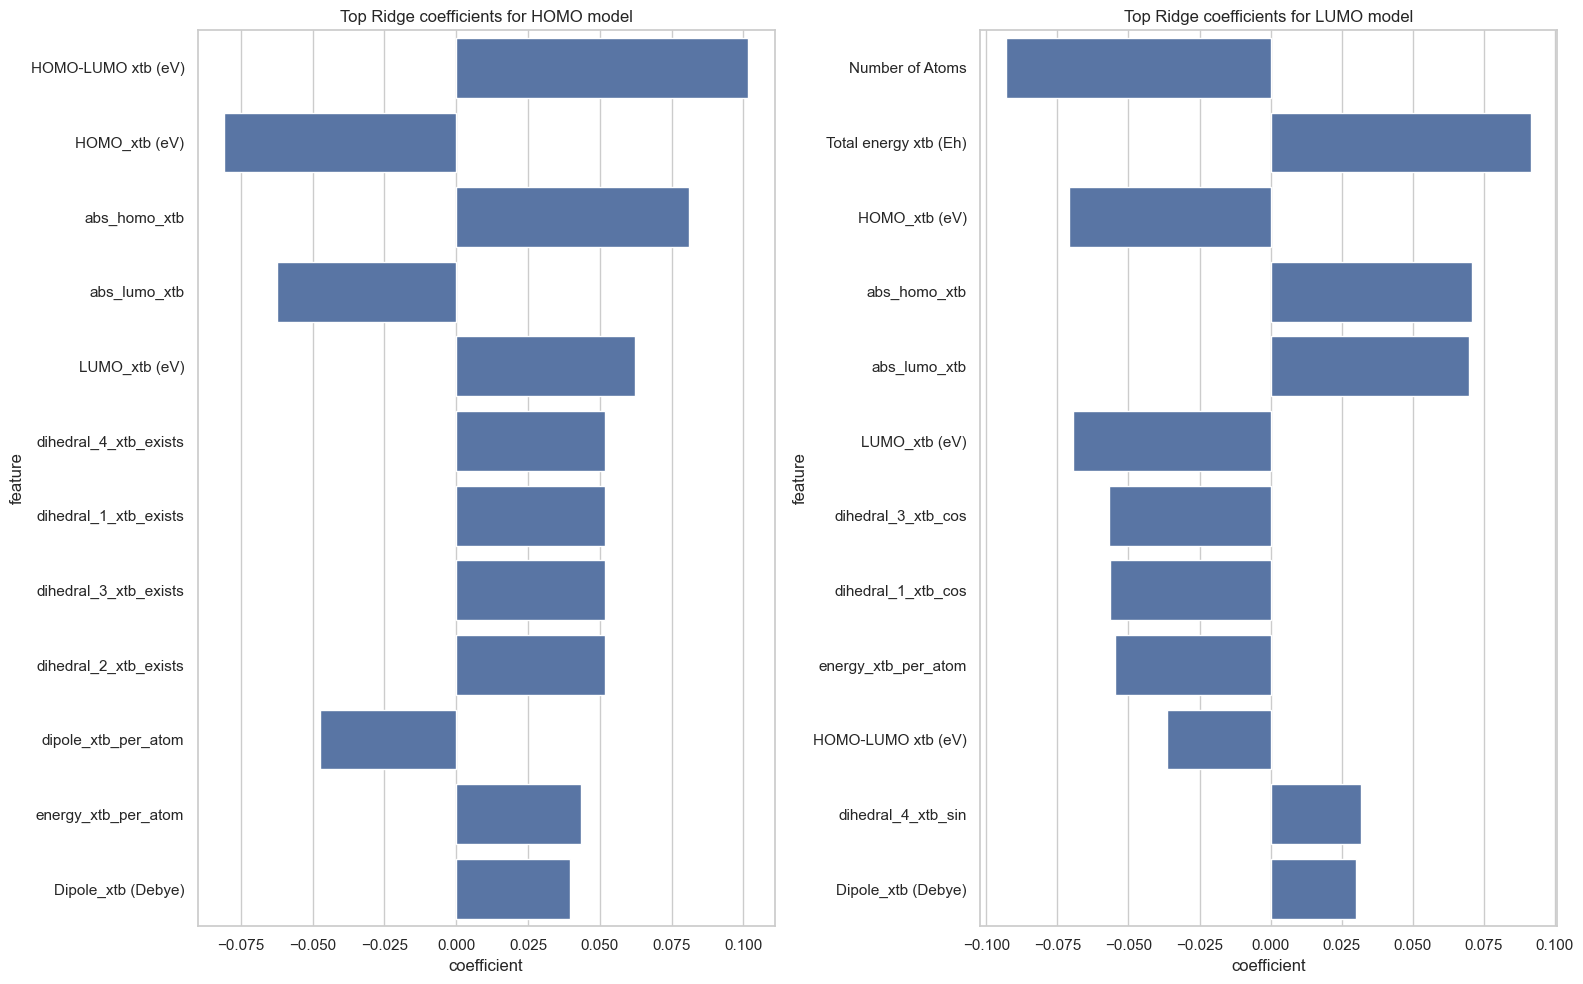

In [64]:

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

sns.barplot(data=homo_coef_df.head(12), y="feature", x="coefficient", ax=axes[0])
axes[0].set_title("Top Ridge coefficients for HOMO model")

sns.barplot(data=lumo_coef_df.head(12), y="feature", x="coefficient", ax=axes[1])
axes[1].set_title("Top Ridge coefficients for LUMO model")

plt.tight_layout()
plt.show()


## 5.2 XGBoost feature importances

In [65]:

energy_importance_df = pd.DataFrame({
    "feature": features_common,
    "importance": best_energy_model.feature_importances_
}).sort_values("importance", ascending=False)

energy_importance_df.head(15)


,feature,importance
8,abs_homo_xtb,0.288242
0,HOMO_xtb (eV),0.224155
12,dihedral_1_xtb_exists,0.051437
9,abs_lumo_xtb,0.046559
2,HOMO-LUMO xtb (eV),0.041575
1,LUMO_xtb (eV),0.040894
13,dihedral_2_xtb_sin,0.040194
14,dihedral_2_xtb_cos,0.037219
5,Number of Atoms,0.036196
7,dipole_xtb_per_atom,0.032343


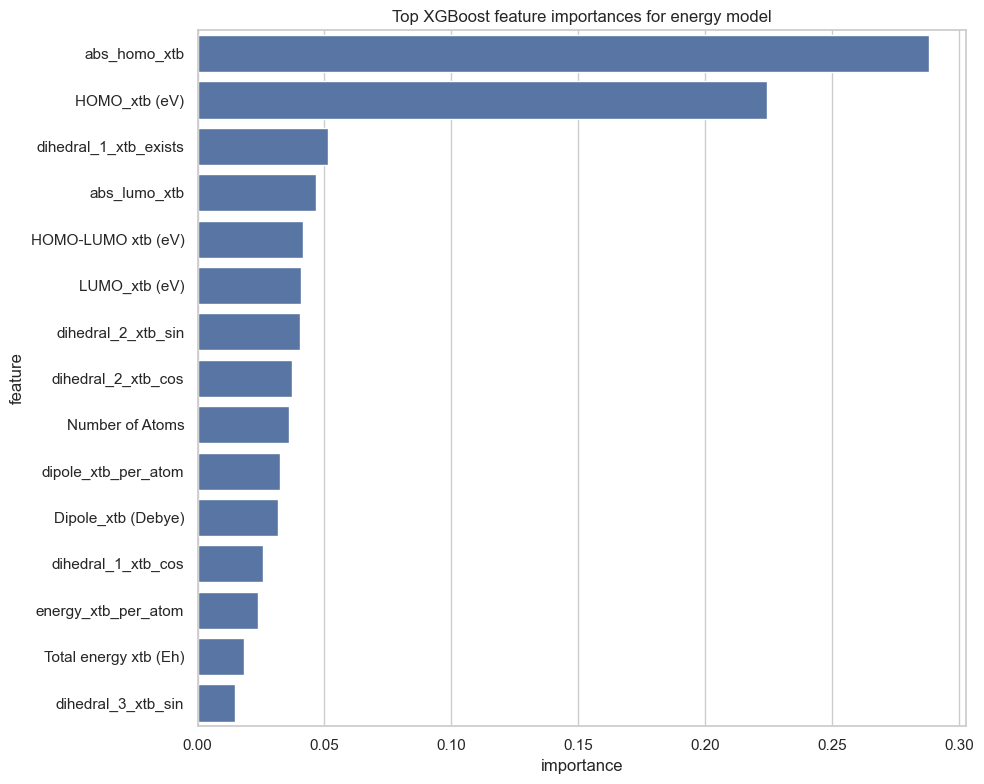

In [66]:

plt.figure(figsize=(10, 8))
sns.barplot(data=energy_importance_df.head(15), y="feature", x="importance")
plt.title("Top XGBoost feature importances for energy model")
plt.tight_layout()
plt.show()


# 6. Results Tables

In [67]:

results_df = pd.DataFrame({
    "Index": X_test.index,

    "Actual_HOMO": homo_true,
    "Predicted_HOMO": homo_pred,
    "Baseline_HOMO_xTB": homo_xtb,
    "Predicted_delta_HOMO": delta_homo_pred,
    "Actual_delta_HOMO": delta_homo_true,

    "Actual_LUMO": lumo_true,
    "Predicted_LUMO": lumo_pred,
    "Baseline_LUMO_xTB": lumo_xtb,
    "Predicted_delta_LUMO": delta_lumo_pred,
    "Actual_delta_LUMO": delta_lumo_true,

    "Actual_Final_Energy": energy_true,
    "Predicted_Final_Energy": energy_pred,
    "Baseline_Final_Energy_xTB": energy_xtb,
    "Predicted_delta_Energy_per_atom": delta_energy_per_atom_pred,
    "Actual_delta_Energy_per_atom": delta_energy_per_atom_true,
    "Number_of_Atoms": n_atoms_test,
})

results_path = os.path.join(OUTPUT_DIR, "test_results_hybrid_homo_lumo_energy.csv")
metrics_path = os.path.join(OUTPUT_DIR, "metrics_hybrid_homo_lumo_energy.csv")
cv_path = os.path.join(OUTPUT_DIR, "cv_metrics_hybrid.csv")

results_df.to_csv(results_path, index=False)
metrics_df.to_csv(metrics_path)
cv_df.to_csv(cv_path, index=False)

print("Saved:", results_path)
print("Saved:", metrics_path)
print("Saved:", cv_path)

results_df.head()


Saved: ./output_hybrid\test_results_hybrid_homo_lumo_energy.csv
Saved: ./output_hybrid\metrics_hybrid_homo_lumo_energy.csv
Saved: ./output_hybrid\cv_metrics_hybrid.csv


,Index,Actual_HOMO,Predicted_HOMO,Baseline_HOMO_xTB,Predicted_delta_HOMO,Actual_delta_HOMO,Actual_LUMO,Predicted_LUMO,Baseline_LUMO_xTB,Predicted_delta_LUMO,Actual_delta_LUMO,Actual_Final_Energy,Predicted_Final_Energy,Baseline_Final_Energy_xTB,Predicted_delta_Energy_per_atom,Actual_delta_Energy_per_atom,Number_of_Atoms
0,181,-5.895535,-5.864123,-9.6774,3.813277,3.781865,-0.767949,-0.789960,-6.6791,5.889140,5.911151,-3905.264349,-4942.478532,-171.840409,-39.755318,-31.111866,120
1,119,-5.862338,-5.870081,-9.6446,3.774519,3.782262,-1.597177,-1.521398,-7.4018,5.880402,5.804623,-7330.305464,-8420.379108,-388.288288,-31.375355,-27.117255,256
2,139,-5.473438,-5.247947,-8.9997,3.751753,3.526262,-1.413829,-1.714830,-7.4366,5.721770,6.022771,-18797.444784,-18848.490529,-798.138722,-33.180794,-33.086960,544
3,216,-5.551098,-5.642677,-9.4465,3.803823,3.895402,-0.301525,-0.148242,-5.8702,5.721958,5.568675,-3501.284984,-3547.969490,-237.736504,-19.703768,-19.425884,168
4,45,-6.099182,-5.838480,-9.7552,3.916720,3.656018,-0.070939,0.156775,-5.6218,5.778575,5.550861,-2781.370286,-3823.293622,-193.945408,-24.522623,-17.482601,148


## 6.1 Hardest energy samples

In [68]:

energy_diagnostics_df = results_df[[
    "Index",
    "Actual_Final_Energy",
    "Predicted_Final_Energy",
    "Baseline_Final_Energy_xTB",
    "Actual_delta_Energy_per_atom",
    "Predicted_delta_Energy_per_atom",
    "Number_of_Atoms",
]].copy()

energy_diagnostics_df["Abs_Error_Final_Energy"] = np.abs(
    energy_diagnostics_df["Actual_Final_Energy"] - energy_diagnostics_df["Predicted_Final_Energy"]
)

energy_diagnostics_df["Abs_Error_delta_Energy_per_atom"] = np.abs(
    energy_diagnostics_df["Actual_delta_Energy_per_atom"] - energy_diagnostics_df["Predicted_delta_Energy_per_atom"]
)

energy_diagnostics_df = energy_diagnostics_df.sort_values(
    "Abs_Error_Final_Energy", ascending=False
).reset_index(drop=True)

energy_diagnostics_path = os.path.join(OUTPUT_DIR, "energy_diagnostics_robust.csv")
energy_diagnostics_df.to_csv(energy_diagnostics_path, index=False)

print("Saved:", energy_diagnostics_path)
energy_diagnostics_df.head(10)


Saved: ./output_hybrid\energy_diagnostics_robust.csv


,Index,Actual_Final_Energy,Predicted_Final_Energy,Baseline_Final_Energy_xTB,Actual_delta_Energy_per_atom,Predicted_delta_Energy_per_atom,Number_of_Atoms,Abs_Error_Final_Energy,Abs_Error_delta_Energy_per_atom
0,177,-19030.159836,-9136.790052,-424.866171,-63.716759,-29.835356,292,9893.369784,33.881403
1,67,-14519.041681,-5137.904342,-217.032211,-91.679548,-31.544052,156,9381.137339,60.135496
2,68,-14676.016116,-5532.129578,-229.689500,-85.990039,-31.562143,168,9143.886537,54.427896
3,9,-13106.215054,-5577.563996,-103.105988,-270.898106,-114.051208,48,7528.651058,156.846897
4,6,-13099.696654,-6048.065867,-204.753703,-153.511226,-69.563240,84,7051.630787,83.947986
5,247,-9226.004733,-3888.670632,-139.352242,-108.174434,-44.634743,84,5337.334101,63.539692
6,86,-4945.956388,-7986.886397,-250.789939,-24.711402,-40.716297,190,3040.930009,16.004895
7,24,-4258.848719,-7291.153732,-181.252670,-39.207654,-68.364433,104,3032.305013,29.156779
8,246,-6801.161980,-4115.866902,-174.633839,-55.221068,-32.843609,120,2685.295078,22.377459
9,73,-10372.108089,-8597.641979,-239.472912,-83.054387,-68.509583,122,1774.466109,14.544804


# 7. Visualization

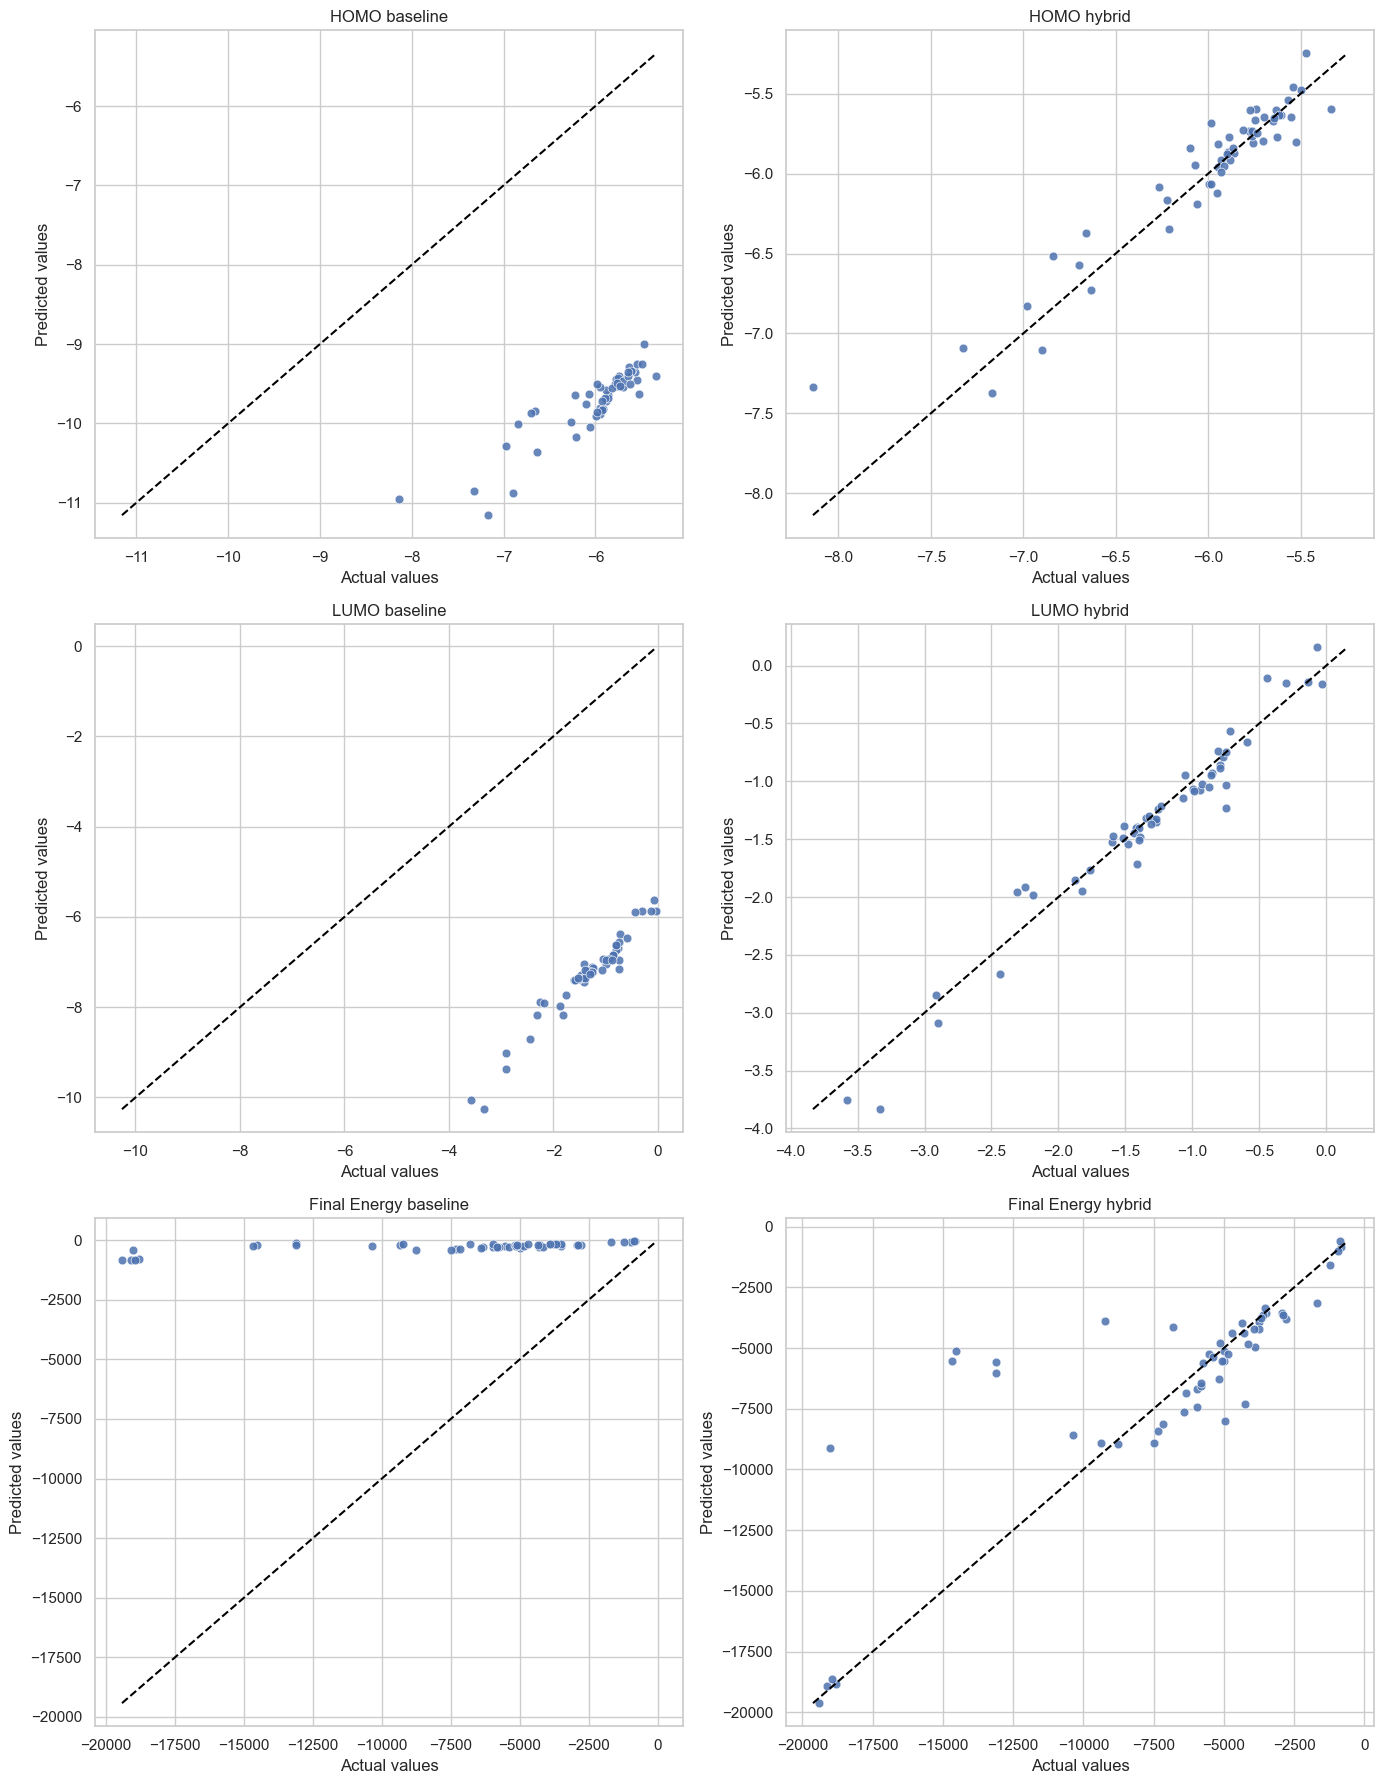

In [69]:

fig, axs = plt.subplots(3, 2, figsize=(14, 18))
axs = axs.flatten()

plot_data = [
    ("HOMO baseline", homo_true, homo_xtb),
    ("HOMO hybrid", homo_true, homo_pred),
    ("LUMO baseline", lumo_true, lumo_xtb),
    ("LUMO hybrid", lumo_true, lumo_pred),
    ("Final Energy baseline", energy_true, energy_xtb),
    ("Final Energy hybrid", energy_true, energy_pred),
]

for i, (title, actual_vals, pred_vals) in enumerate(plot_data):
    ax = axs[i]
    sns.scatterplot(x=actual_vals, y=pred_vals, ax=ax, alpha=0.85, s=40)

    min_val = min(np.min(actual_vals), np.min(pred_vals))
    max_val = max(np.max(actual_vals), np.max(pred_vals))
    ax.plot([min_val, max_val], [min_val, max_val], "--", color="black")

    ax.set_title(title)
    ax.set_xlabel("Actual values")
    ax.set_ylabel("Predicted values")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_model_parity_plots.png"), dpi=300, bbox_inches="tight")
plt.show()


## 7.1 Error distributions

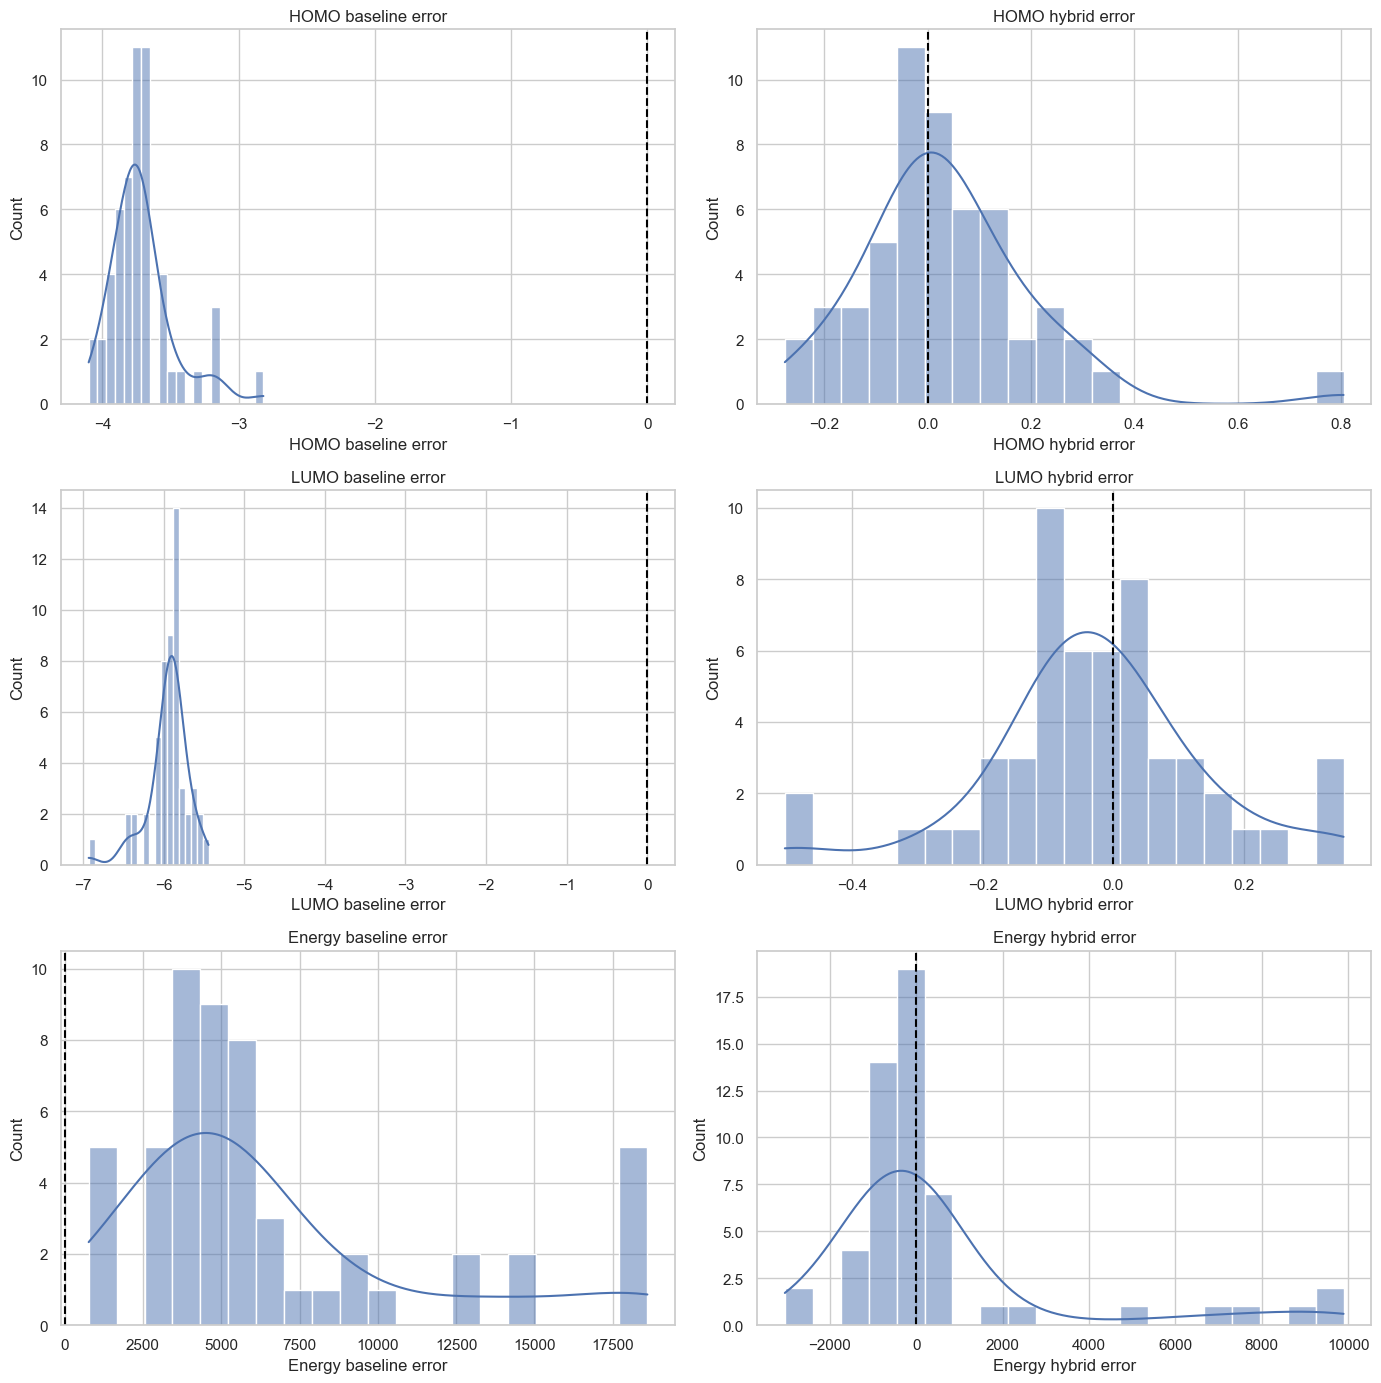

In [70]:

error_df = pd.DataFrame({
    "HOMO baseline error": homo_xtb - homo_true,
    "HOMO hybrid error": homo_pred - homo_true,
    "LUMO baseline error": lumo_xtb - lumo_true,
    "LUMO hybrid error": lumo_pred - lumo_true,
    "Energy baseline error": energy_xtb - energy_true,
    "Energy hybrid error": energy_pred - energy_true,
})

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(error_df.columns):
    sns.histplot(error_df[col], bins=20, kde=True, ax=axes[i])
    axes[i].axvline(0, linestyle="--", color="black")
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


## 7.2 Residuals vs predictions

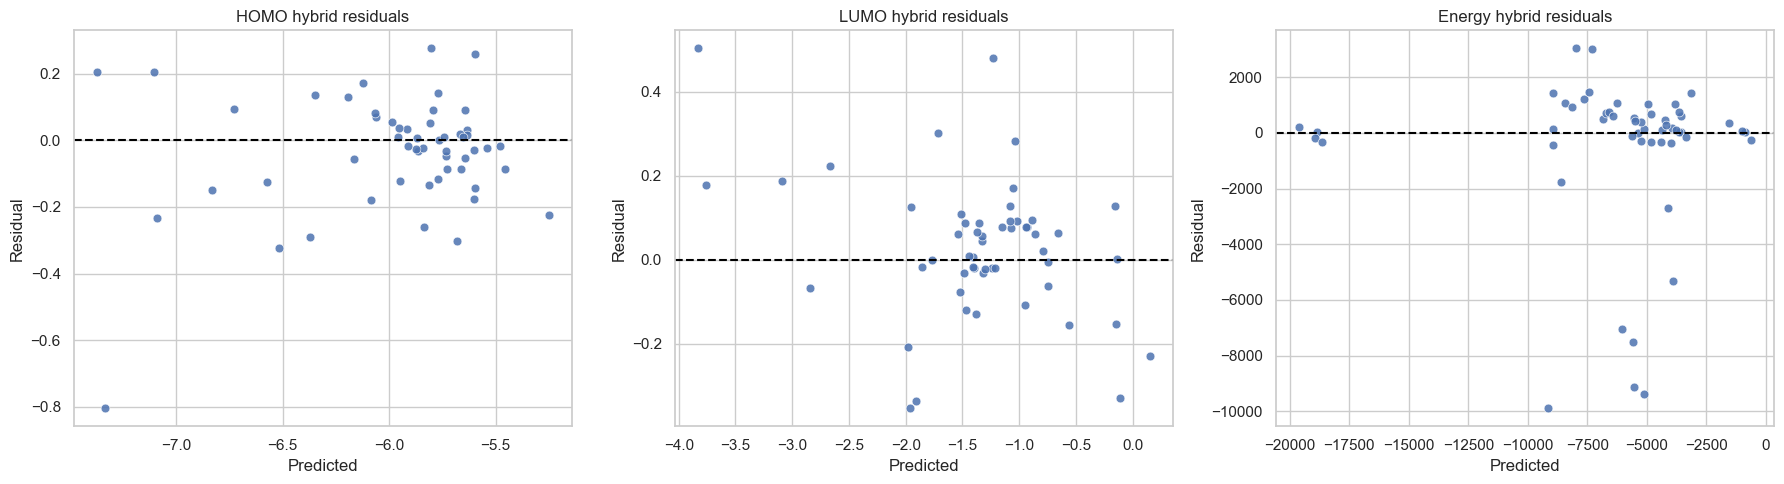

In [71]:

residual_plots = [
    ("HOMO hybrid residuals", homo_pred, homo_true - homo_pred),
    ("LUMO hybrid residuals", lumo_pred, lumo_true - lumo_pred),
    ("Energy hybrid residuals", energy_pred, energy_true - energy_pred),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (title, preds, residuals) in zip(axes, residual_plots):
    sns.scatterplot(x=preds, y=residuals, ax=ax, s=40, alpha=0.85)
    ax.axhline(0, linestyle="--", color="black")
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Residual")

plt.tight_layout()
plt.show()
